In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, silhouette_score, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [19]:

!apt-get install -y fonts-dejavu-core fonts-dejavu-extra
!fc-cache -fv

import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-dejavu-core is already the newest version (2.37-2build1).
fonts-dejavu-extra is already the newest version (2.37-2build1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/dejavu: caching, new cache contents: 22 fonts, 0 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/dejavu: skipping, looped directory detected
/usr/share/fonts/truetype/humo

In [20]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('SuperStore.csv', header=None, names=[
    'Order_ID', 'Order_Date', 'Customer_ID', 'Sales', 'Quantity',
    'Discount', 'Profit', 'Segment', 'Category', 'Sub_Category',
    'City', 'State', 'Region', 'Ship_Mode'
])

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

print("Đọc dữ liệu thành công!")
print(f" Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột")

Saving SuperStore.csv to SuperStore.csv
Đọc dữ liệu thành công!
 Kích thước: 9825 dòng x 14 cột


In [22]:

print("="*70)
print(" KHÁM PHÁ DỮ LIỆU (EXPLORATORY DATA ANALYSIS)")
print("="*70)

print("\n THÔNG TIN CƠ BẢN:")
print(f"Số đơn hàng: {len(df):,}")
print(f"Số khách hàng: {df['Customer_ID'].nunique():,}")
print(f"Thời gian: {df['Order_Date'].min().date()} đến {df['Order_Date'].max().date()}")
print(f"Tổng doanh thu: ${df['Sales'].sum():,.2f}")
print(f"Tổng lợi nhuận: ${df['Profit'].sum():,.2f}")


print("\n 5 DÒNG ĐẦU TIÊN:")
display(df.head())


print("\n THỐNG KÊ MÔ TẢ:")
display(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe())


print("\n MISSING VALUES:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print(" Không có missing values!")
else:
    print(missing[missing > 0])

 KHÁM PHÁ DỮ LIỆU (EXPLORATORY DATA ANALYSIS)

 THÔNG TIN CƠ BẢN:
Số đơn hàng: 9,825
Số khách hàng: 793
Thời gian: 2014-01-03 đến 2017-12-30
Tổng doanh thu: $2,258,787.07
Tổng lợi nhuận: $278,870.44

 5 DÒNG ĐẦU TIÊN:


,Order_ID,Order_Date,Customer_ID,Sales,Quantity,Discount,Profit,Segment,Category,Sub_Category,City,State,Region,Ship_Mode
0,CA-2017-140326,2017-09-04,HW-14935,825.174,9,0.30,-117.8820,Corporate,Furniture,Bookcases,Chicago,Illinois,Central,First Class
1,CA-2017-125472,2017-05-30,BD-11725,241.960,2,0.00,33.8744,Consumer,Furniture,Bookcases,Lafayette,Louisiana,South,First Class
2,CA-2014-105249,2014-11-28,DH-13675,411.332,4,0.15,-4.8392,Home Office,Furniture,Bookcases,San Francisco,California,West,Same Day
3,CA-2015-130785,2015-09-05,AG-10900,411.332,4,0.15,-4.8392,Consumer,Furniture,Bookcases,San Diego,California,West,Standard Class
4,CA-2014-133592,2014-12-31,KM-16375,341.960,2,0.00,78.6508,Home Office,Furniture,Bookcases,Providence,Rhode Island,East,Standard Class



 THỐNG KÊ MÔ TẢ:


,Sales,Quantity,Discount,Profit
count,9825.000000,9825.000000,9825.00000,9825.000000
mean,229.901992,3.788193,0.15692,28.383759
std,626.134604,2.223977,0.20724,235.599842
min,0.444000,1.000000,0.00000,-6599.978000
25%,17.120000,2.000000,0.00000,1.705200
50%,53.900000,3.000000,0.20000,8.554400
75%,209.880000,5.000000,0.20000,29.152800
max,22638.480000,14.000000,0.80000,8399.976000



 MISSING VALUES:
 Không có missing values!



VISUALIZATION - PHÂN TÍCH MÔ TẢ


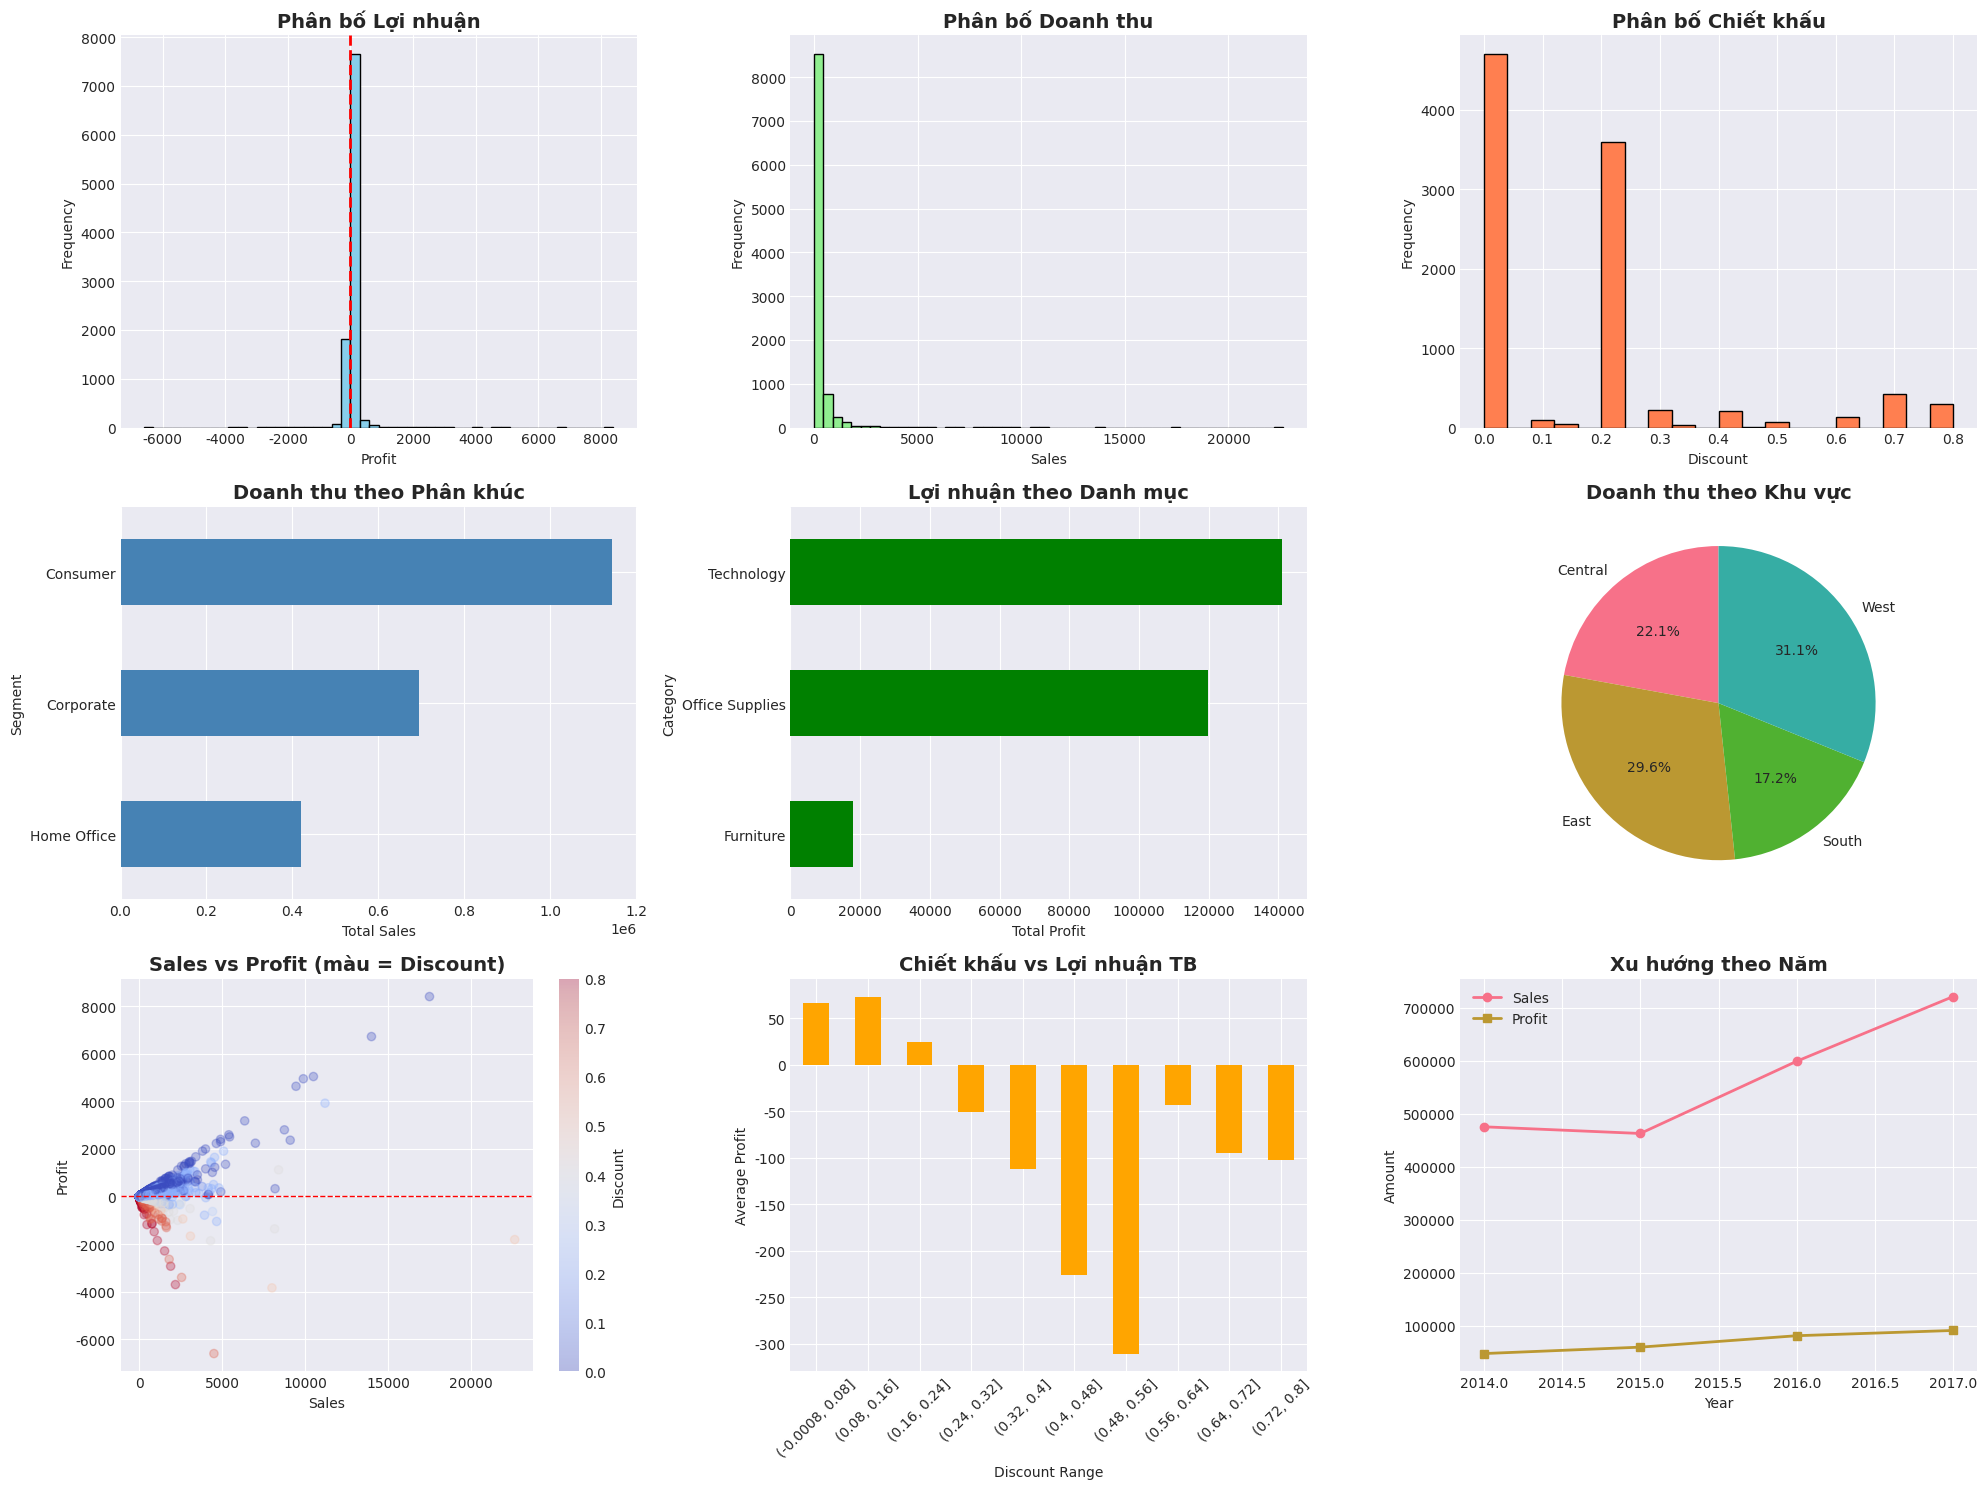

In [23]:

print("\n" + "="*70)
print("VISUALIZATION - PHÂN TÍCH MÔ TẢ")
print("="*70)

# Tạo figure với nhiều subplots
fig = plt.figure(figsize=(20, 15))

# 1. Phân bố Profit
plt.subplot(3, 3, 1)
plt.hist(df['Profit'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title('Phân bố Lợi nhuận', fontsize=14, fontweight='bold')
plt.xlabel('Profit')
plt.ylabel('Frequency')

# 2. Phân bố Sales
plt.subplot(3, 3, 2)
plt.hist(df['Sales'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Phân bố Doanh thu', fontsize=14, fontweight='bold')
plt.xlabel('Sales')
plt.ylabel('Frequency')

# 3. Phân bố Discount
plt.subplot(3, 3, 3)
plt.hist(df['Discount'], bins=20, color='coral', edgecolor='black')
plt.title('Phân bố Chiết khấu', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Frequency')

# 4. Sales theo Segment
plt.subplot(3, 3, 4)
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values()
segment_sales.plot(kind='barh', color='steelblue')
plt.title('Doanh thu theo Phân khúc', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales')

# 5. Profit theo Category
plt.subplot(3, 3, 5)
category_profit = df.groupby('Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'green' for x in category_profit]
category_profit.plot(kind='barh', color=colors)
plt.title('Lợi nhuận theo Danh mục', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit')

# 6. Sales theo Region
plt.subplot(3, 3, 6)
region_sales = df.groupby('Region')['Sales'].sum()
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('Doanh thu theo Khu vực', fontsize=14, fontweight='bold')

# 7. Scatter: Sales vs Profit
plt.subplot(3, 3, 7)
plt.scatter(df['Sales'], df['Profit'], alpha=0.3, c=df['Discount'], cmap='coolwarm')
plt.colorbar(label='Discount')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Sales vs Profit (màu = Discount)', fontsize=14, fontweight='bold')
plt.xlabel('Sales')
plt.ylabel('Profit')

# 8. Discount vs Profit
plt.subplot(3, 3, 8)
discount_profit = df.groupby(pd.cut(df['Discount'], bins=10))['Profit'].mean()
discount_profit.plot(kind='bar', color='orange')
plt.title('Chiết khấu vs Lợi nhuận TB', fontsize=14, fontweight='bold')
plt.xlabel('Discount Range')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)

# 9. Xu hướng theo thời gian
plt.subplot(3, 3, 9)
df['Year'] = df['Order_Date'].dt.year
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_profit = df.groupby('Year')['Profit'].sum()
x = yearly_sales.index
plt.plot(x, yearly_sales.values, marker='o', label='Sales', linewidth=2)
plt.plot(x, yearly_profit.values, marker='s', label='Profit', linewidth=2)
plt.title('Xu hướng theo Năm', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



 FEATURE ENGINEERING

 Phân bố Profitable:
   Lãi (1): 7,912 (80.5%)
   Lỗ (0): 1,913 (19.5%)


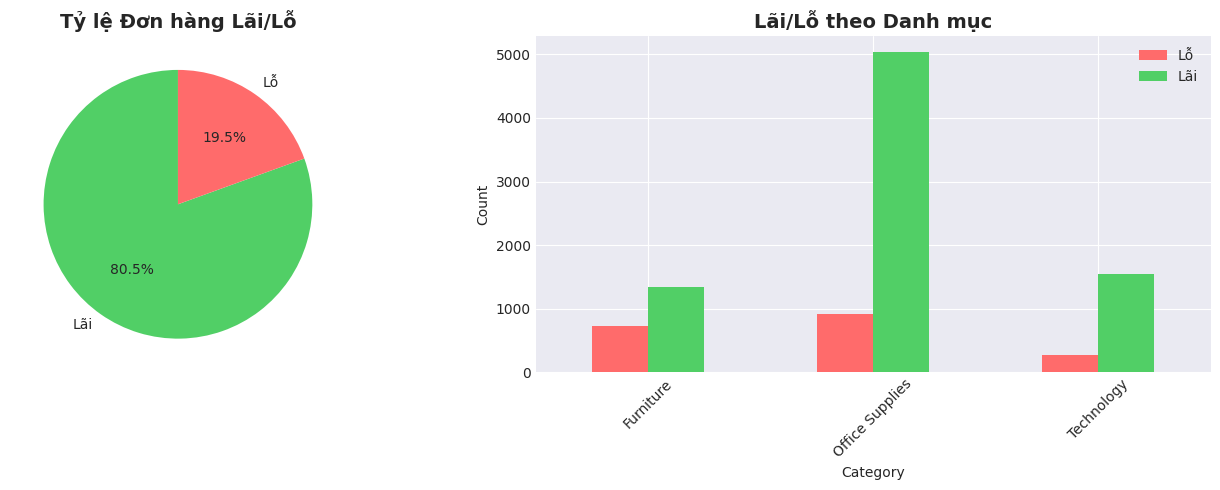

In [27]:

print("\n" + "="*70)
print(" FEATURE ENGINEERING")
print("="*70)

# Tạo biến mới
df['Profitable'] = (df['Profit'] > 0).astype(int)
df['Profit_Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)
df['Price_Per_Unit'] = (df['Sales'] / df['Quantity']).round(2)
df['Month'] = df['Order_Date'].dt.month
df['Quarter'] = df['Order_Date'].dt.quarter
df['DayOfWeek'] = df['Order_Date'].dt.dayofweek


# Phân tích Profitable
profitable_count = df['Profitable'].value_counts()
print(f"\n Phân bố Profitable:")
print(f"   Lãi (1): {profitable_count[1]:,} ({profitable_count[1]/len(df)*100:.1f}%)")
print(f"   Lỗ (0): {profitable_count[0]:,} ({profitable_count[0]/len(df)*100:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(profitable_count, labels=['Lãi', 'Lỗ'], autopct='%1.1f%%',
            colors=['#51cf66', '#ff6b6b'], startangle=90)
axes[0].set_title('Tỷ lệ Đơn hàng Lãi/Lỗ', fontsize=14, fontweight='bold')

# Bar chart theo Category
profit_by_cat = df.groupby(['Category', 'Profitable']).size().unstack()
profit_by_cat.plot(kind='bar', ax=axes[1], color=['#ff6b6b', '#51cf66'])
axes[1].set_title('Lãi/Lỗ theo Danh mục', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].legend(['Lỗ', 'Lãi'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [26]:

print("\n" + "="*70)
print("BƯỚC 3: ENCODING VÀ CHUẨN BỊ DỮ LIỆU")
print("="*70)

# Label Encoding
le = LabelEncoder()
df_encoded = df.copy()

categorical_cols = ['Segment', 'Category', 'Sub_Category', 'Region', 'Ship_Mode']
for col in categorical_cols:
    df_encoded[f'{col}_Encoded'] = le.fit_transform(df_encoded[col])
    print(f" Encoded: {col}")

# Chuẩn bị dữ liệu cho Classification
classification_features = [
    'Sales', 'Quantity', 'Discount', 'Segment_Encoded',
    'Category_Encoded', 'Region_Encoded', 'Ship_Mode_Encoded',
    'Month', 'Quarter'
]

X = df_encoded[classification_features]
y = df_encoded['Profitable']

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n Chia dữ liệu:")
print(f"   Training: {X_train.shape[0]} samples")
print(f"   Testing: {X_test.shape[0]} samples")
print(f"   Features: {len(classification_features)}")



BƯỚC 3: ENCODING VÀ CHUẨN BỊ DỮ LIỆU
 Encoded: Segment
 Encoded: Category
 Encoded: Sub_Category
 Encoded: Region
 Encoded: Ship_Mode

 Chia dữ liệu:
   Training: 6877 samples
   Testing: 2948 samples
   Features: 9



THUẬT TOÁN 1: DECISION TREE CLASSIFIER

 KẾT QUẢ DECISION TREE:
   Accuracy:  0.9389 (93.89%)
   Precision: 0.9329
   Recall:    0.9958
   F1-Score:  0.9633


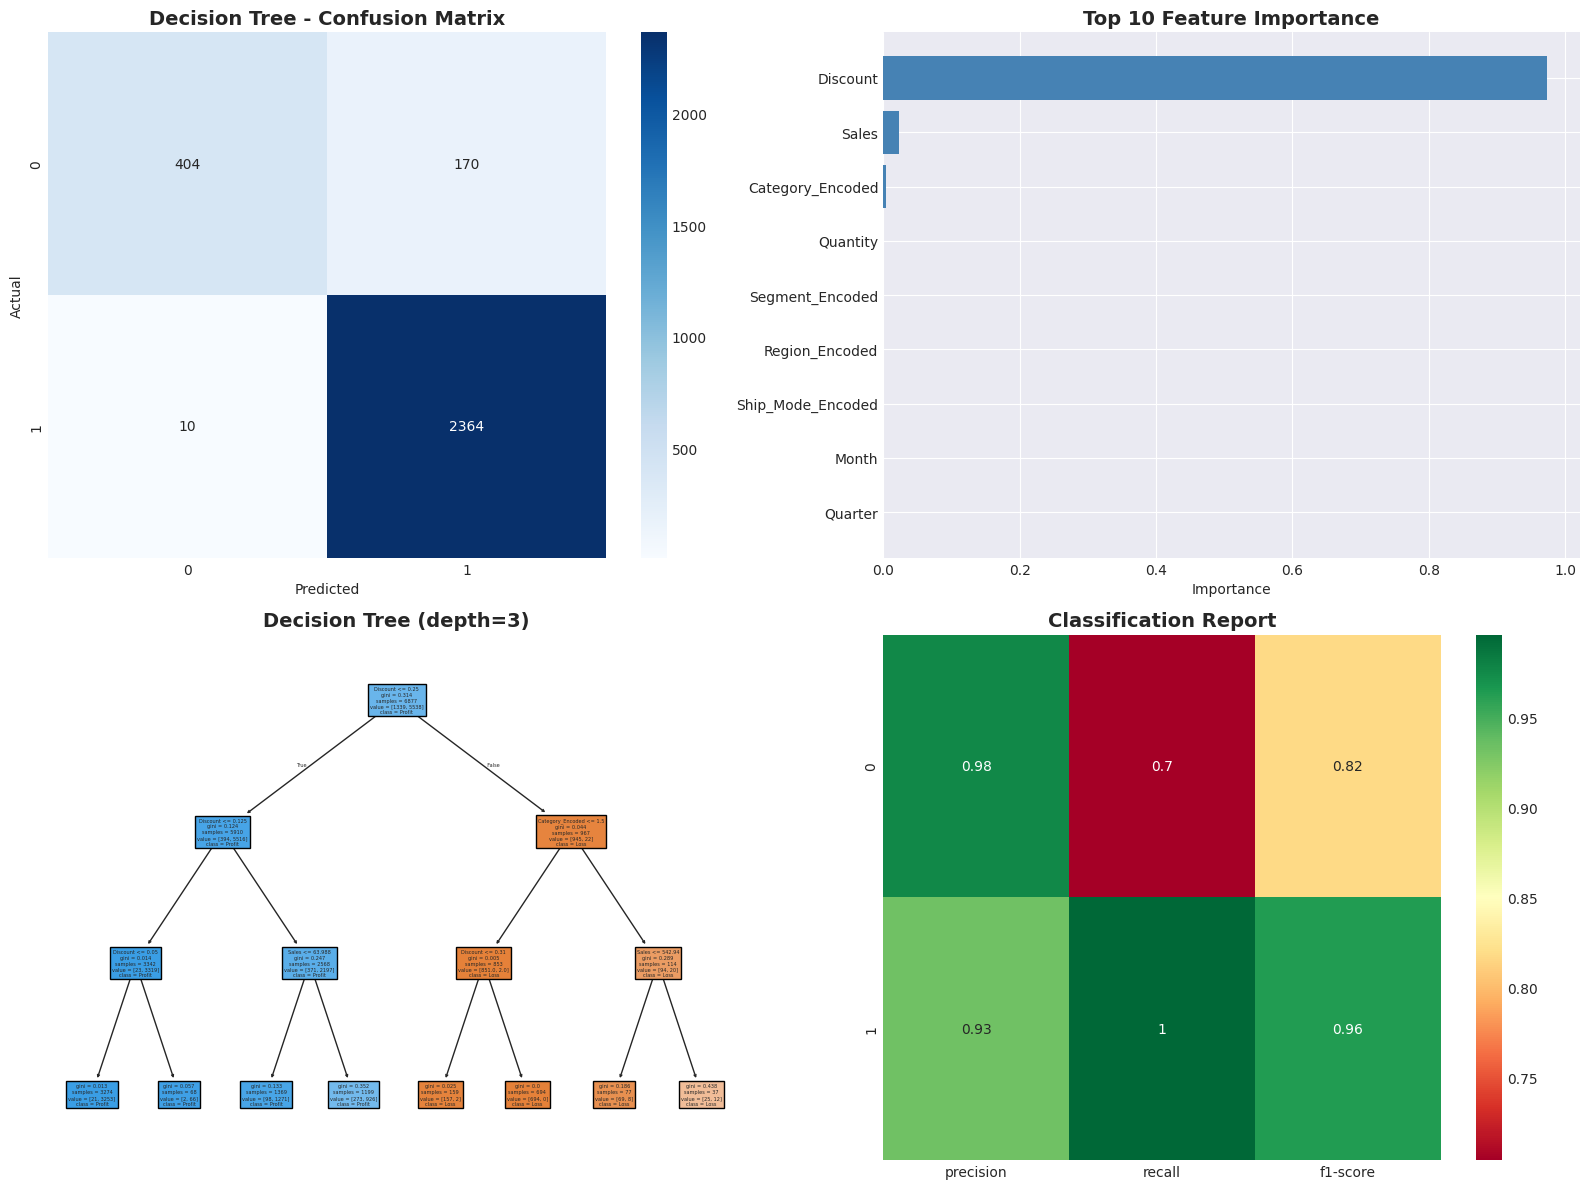


 TOP 5 FEATURES QUAN TRỌNG:
            Feature  Importance
2          Discount    0.973108
0             Sales    0.022801
4  Category_Encoded    0.004091
1          Quantity    0.000000
3   Segment_Encoded    0.000000


In [28]:

print("\n" + "="*70)
print("THUẬT TOÁN 1: DECISION TREE CLASSIFIER")
print("="*70)

# Huấn luyện Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)


dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Đánh giá
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print(f"\n KẾT QUẢ DECISION TREE:")
print(f"   Accuracy:  {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print(f"   Precision: {dt_precision:.4f}")
print(f"   Recall:    {dt_recall:.4f}")
print(f"   F1-Score:  {dt_f1:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Decision Tree - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# 2. Feature Importance
feature_importance_dt = pd.DataFrame({
    'Feature': classification_features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

axes[0, 1].barh(feature_importance_dt['Feature'][:10],
                feature_importance_dt['Importance'][:10],
                color='steelblue')
axes[0, 1].set_title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Importance')
axes[0, 1].invert_yaxis()


# 3. Decision Tree Visualization (simplified)
plot_tree(dt_model, max_depth=3, feature_names=classification_features,
          class_names=['Loss', 'Profit'], filled=True, ax=axes[1, 0])
axes[1, 0].set_title('Decision Tree (depth=3)', fontsize=14, fontweight='bold')
# 4. Classification Report as heatmap
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
report_df = pd.DataFrame(report_dt).iloc[:-1, :].T
sns.heatmap(report_df.iloc[:2, :3], annot=True, cmap='RdYlGn', ax=axes[1, 1])
axes[1, 1].set_title('Classification Report', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n TOP 5 FEATURES QUAN TRỌNG:")
print(feature_importance_dt.head())



DECISION TREE VISUALIZATION


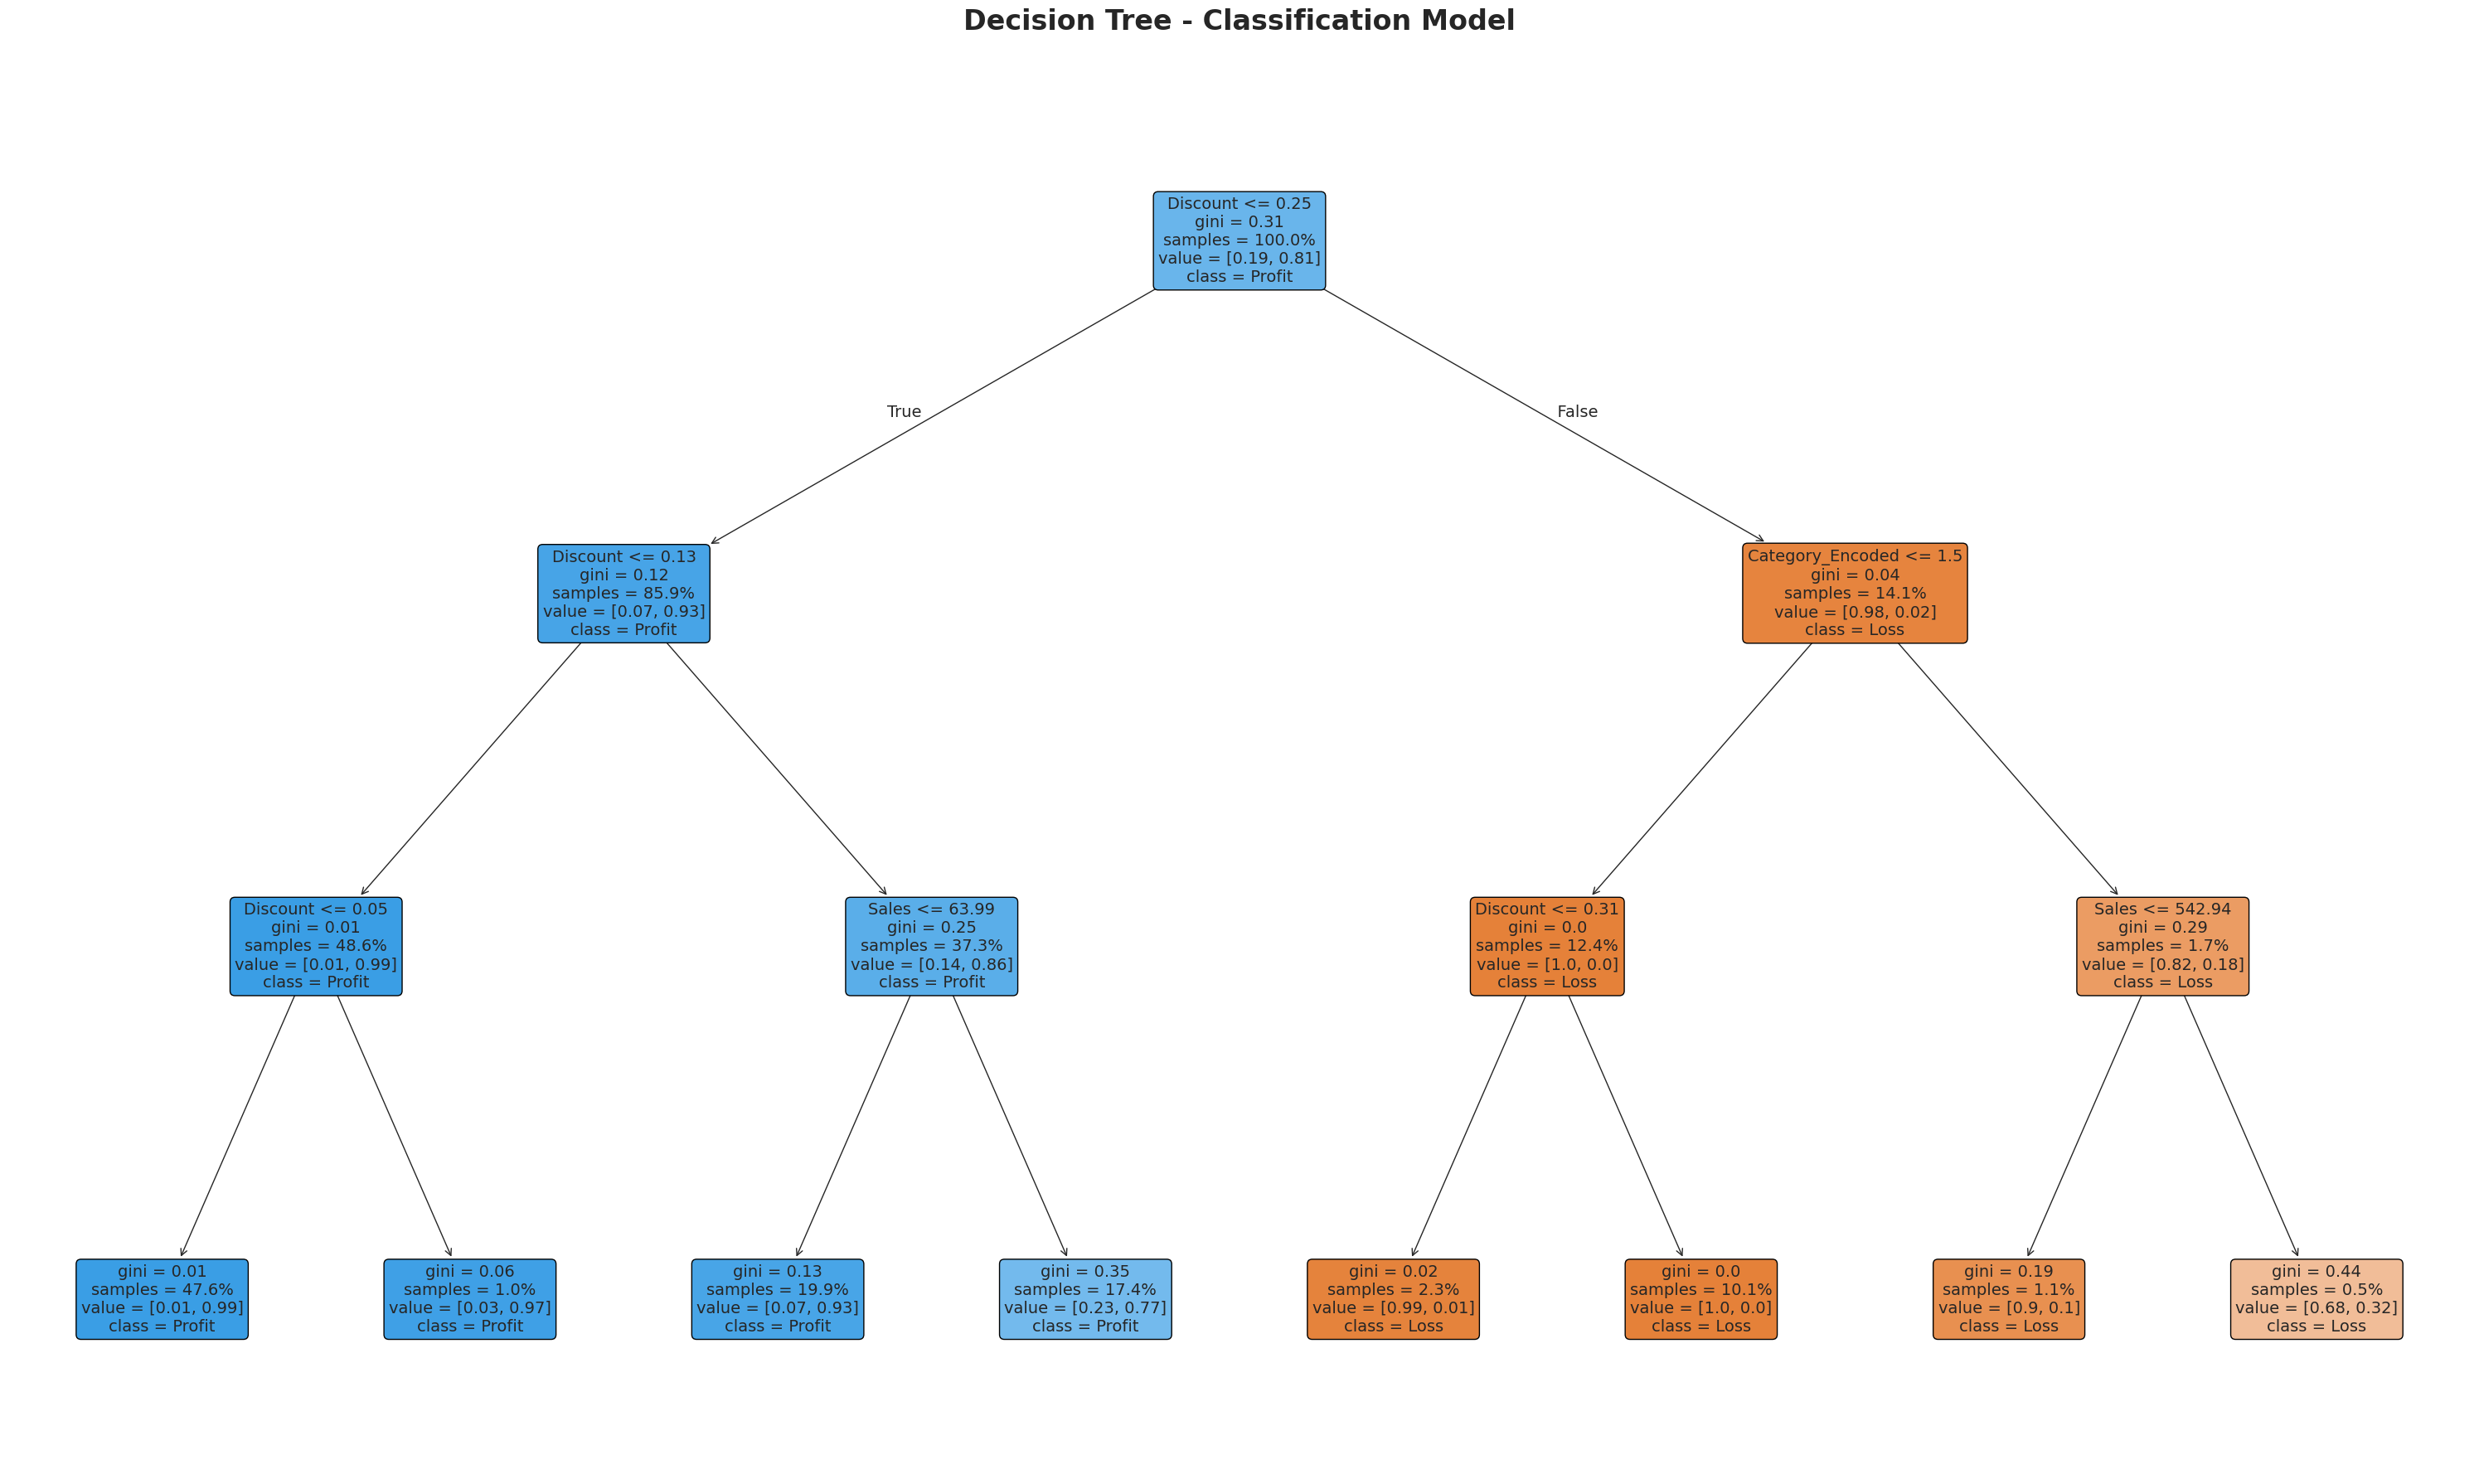


 Thông tin cây:
   • Độ sâu hiển thị: 3 tầng
   • Độ sâu thực tế: 3 tầng
   • Tổng nodes: 15
   • Leaf nodes: 8


In [29]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print("="*70)
print("DECISION TREE VISUALIZATION")
print("="*70)

# Vẽ cây Decision Tree với kích thước rất lớn
fig = plt.figure(figsize=(30, 18))

plot_tree(dt_model,
          max_depth=3,
          feature_names=classification_features,
          class_names=['Loss', 'Profit'],
          filled=True,
          rounded=True,
          fontsize=14,
          proportion=True,
          precision=2)

plt.title('Decision Tree - Classification Model',
          fontsize=24, fontweight='bold', pad=30)


plt.tight_layout()
plt.show()

print(f"\n Thông tin cây:")
print(f"   • Độ sâu hiển thị: 3 tầng")
print(f"   • Độ sâu thực tế: {dt_model.get_depth()} tầng")
print(f"   • Tổng nodes: {dt_model.tree_.node_count}")
print(f"   • Leaf nodes: {dt_model.tree_.n_leaves}")



THUẬT TOÁN 2: RANDOM FOREST CLASSIFIER

 KẾT QUẢ RANDOM FOREST:
   Accuracy:  0.9393 (93.93%)
   Precision: 0.9340
   Recall:    0.9949
   F1-Score:  0.9635


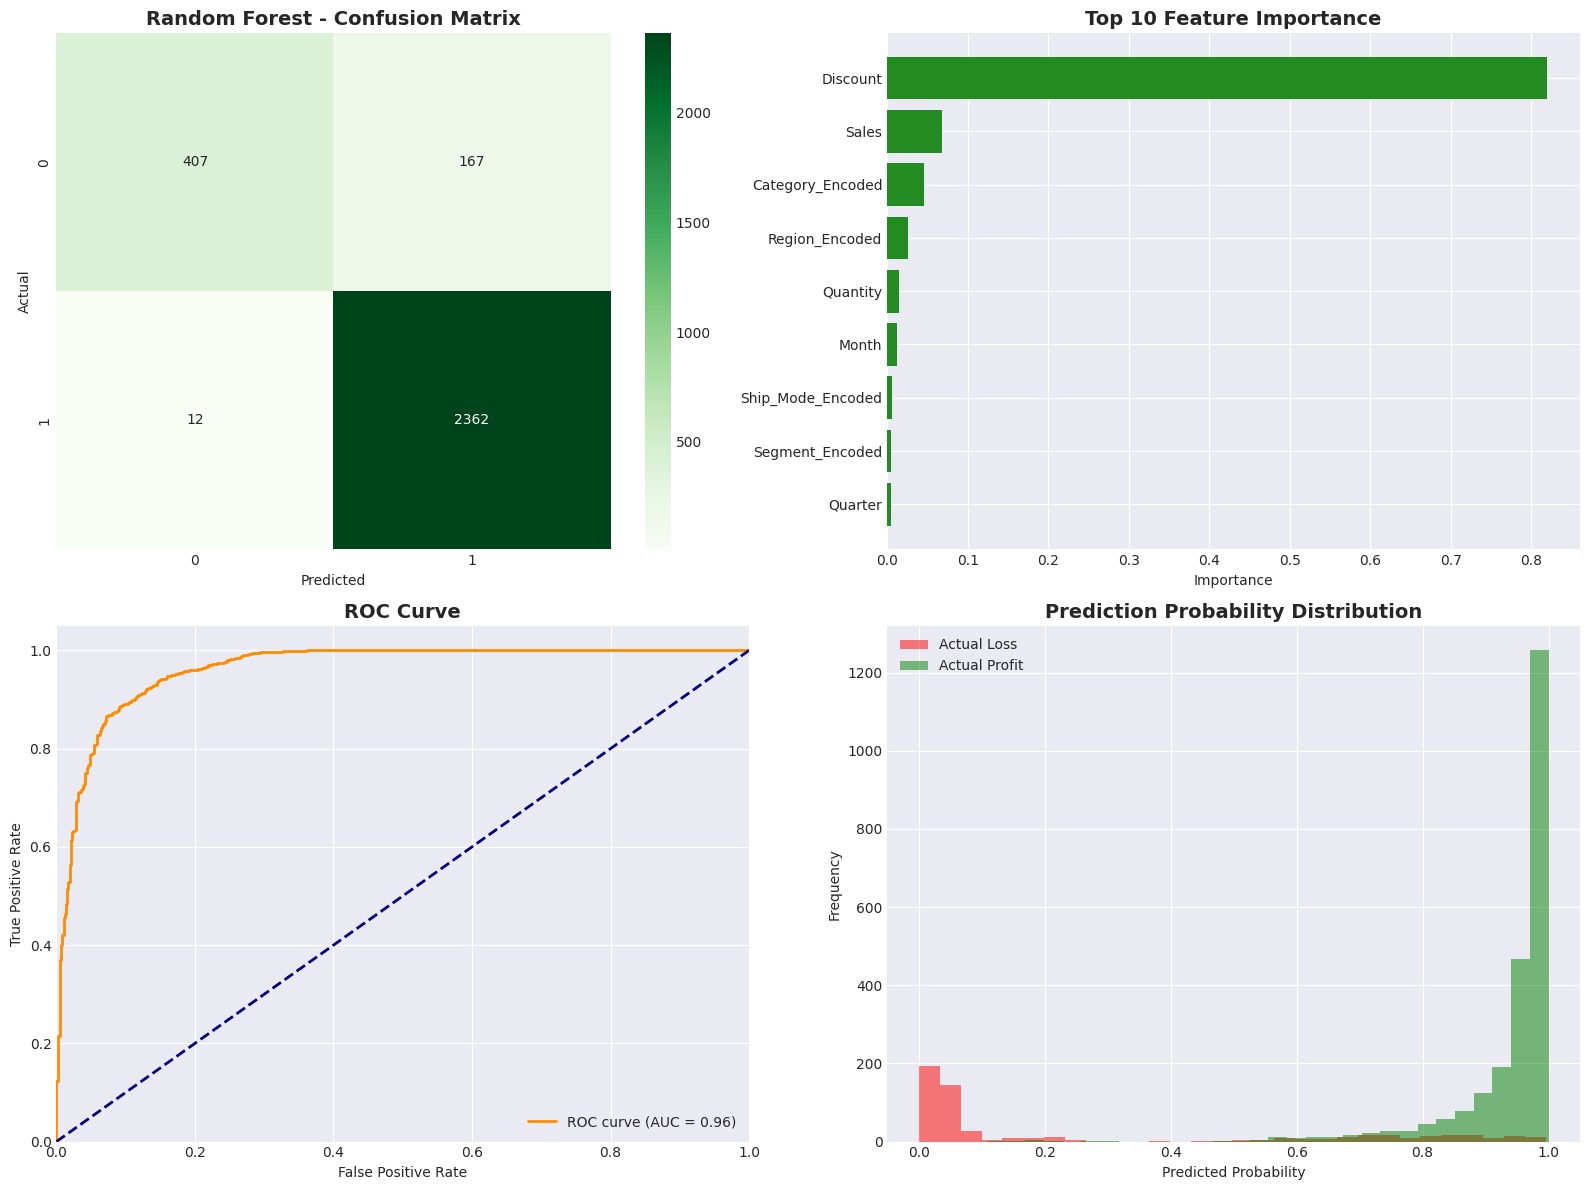


 TOP 5 FEATURES QUAN TRỌNG:
            Feature  Importance
2          Discount    0.819732
0             Sales    0.067786
4  Category_Encoded    0.045894
5    Region_Encoded    0.025203
1          Quantity    0.014605


In [30]:

print("\n" + "="*70)
print("THUẬT TOÁN 2: RANDOM FOREST CLASSIFIER")
print("="*70)

# Huấn luyện Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)


rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]


# Đánh giá
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"\n KẾT QUẢ RANDOM FOREST:")
print(f"   Accuracy:  {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"   Precision: {rf_precision:.4f}")
print(f"   Recall:    {rf_recall:.4f}")
print(f"   F1-Score:  {rf_f1:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0, 0])
axes[0, 0].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# 2. Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': classification_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

axes[0, 1].barh(feature_importance_rf['Feature'][:10],
                feature_importance_rf['Importance'][:10],
                color='forestgreen')
axes[0, 1].set_title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Importance')
axes[0, 1].invert_yaxis()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc = auc(fpr, tpr)
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc="lower right")
axes[1, 0].grid(True)

# 4. Prediction Distribution
axes[1, 1].hist(y_pred_proba_rf[y_test == 0], bins=30, alpha=0.5,
                label='Actual Loss', color='red')
axes[1, 1].hist(y_pred_proba_rf[y_test == 1], bins=30, alpha=0.5,
                label='Actual Profit', color='green')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("\n TOP 5 FEATURES QUAN TRỌNG:")
print(feature_importance_rf.head())



SO SÁNH DECISION TREE vs RANDOM FOREST
   Metric  Decision Tree  Random Forest
 Accuracy       0.938942       0.939281
Precision       0.932912       0.933966
   Recall       0.995788       0.994945
 F1-Score       0.963325       0.963492


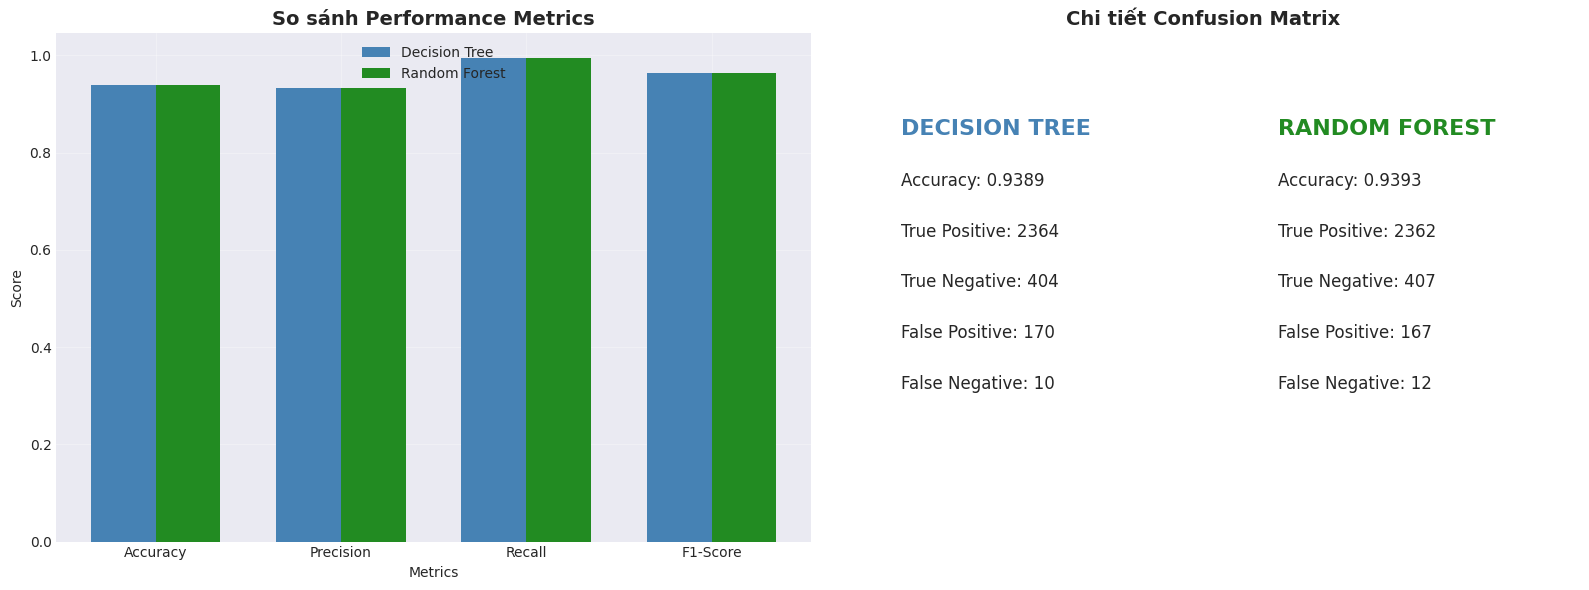

In [31]:

print("\n" + "="*70)
print("SO SÁNH DECISION TREE vs RANDOM FOREST")
print("="*70)

# Tạo bảng so sánh
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [dt_accuracy, dt_precision, dt_recall, dt_f1],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1]
})

print(comparison_df.to_string(index=False))

# Visualization so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar chart so sánh metrics
x = np.arange(len(comparison_df['Metric']))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Decision Tree'], width,
            label='Decision Tree', color='steelblue')
axes[0].bar(x + width/2, comparison_df['Random Forest'], width,
            label='Random Forest', color='forestgreen')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('So sánh Performance Metrics', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Metric'])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Confusion Matrix so sánh
axes[1].text(0.1, 0.8, 'DECISION TREE', fontsize=16, fontweight='bold', color='steelblue')
axes[1].text(0.1, 0.7, f'Accuracy: {dt_accuracy:.4f}', fontsize=12)
axes[1].text(0.1, 0.6, f'True Positive: {cm_dt[1,1]}', fontsize=12)
axes[1].text(0.1, 0.5, f'True Negative: {cm_dt[0,0]}', fontsize=12)
axes[1].text(0.1, 0.4, f'False Positive: {cm_dt[0,1]}', fontsize=12)
axes[1].text(0.1, 0.3, f'False Negative: {cm_dt[1,0]}', fontsize=12)

axes[1].text(0.6, 0.8, 'RANDOM FOREST', fontsize=16, fontweight='bold', color='forestgreen')
axes[1].text(0.6, 0.7, f'Accuracy: {rf_accuracy:.4f}', fontsize=12)
axes[1].text(0.6, 0.6, f'True Positive: {cm_rf[1,1]}', fontsize=12)
axes[1].text(0.6, 0.5, f'True Negative: {cm_rf[0,0]}', fontsize=12)
axes[1].text(0.6, 0.4, f'False Positive: {cm_rf[0,1]}', fontsize=12)
axes[1].text(0.6, 0.3, f'False Negative: {cm_rf[1,0]}', fontsize=12)

axes[1].axis('off')
axes[1].set_title('Chi tiết Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



In [35]:

print("\n" + "="*70)
print("CHUẨN BỊ DỮ LIỆU CHO CLUSTERING")
print("="*70)

# Tạo customer profile
customer_profile = df_encoded.groupby('Customer_ID').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index()

customer_profile.columns = ['Customer_ID', 'Total_Sales', 'Avg_Sales', 'Order_Count',
                            'Total_Profit', 'Avg_Profit', 'Total_Quantity', 'Avg_Discount']


display(customer_profile.describe())

# Chuẩn hóa dữ liệu
clustering_features = ['Total_Sales', 'Avg_Sales', 'Order_Count',
                       'Total_Profit', 'Avg_Profit', 'Total_Quantity', 'Avg_Discount']

scaler = StandardScaler()
X_cluster = scaler.fit_transform(customer_profile[clustering_features])

print(f"\n Đã chuẩn hóa {len(clustering_features)} features")
# Hiển thị so sánh TRƯỚC và SAU chuẩn hóa
print("\n" + "="*70)
print("SO SÁNH TRƯỚC VÀ SAU CHUẨN HÓA")
print("="*70)

print("\n TRƯỚC chuẩn hóa (5 khách hàng đầu):")
print(customer_profile[clustering_features].head())

print("\n SAU chuẩn hóa (5 khách hàng đầu):")
X_cluster_df = pd.DataFrame(X_cluster, columns=clustering_features)
print(X_cluster_df.head())

print("\n THỐNG KÊ SAU CHUẨN HÓA:")
print(f"   Mean (trung bình): {X_cluster.mean(axis=0).round(4)}")
print(f"   Std (độ lệch chuẩn): {X_cluster.std(axis=0).round(4)}")



CHUẨN BỊ DỮ LIỆU CHO CLUSTERING


,Total_Sales,Avg_Sales,Order_Count,Total_Profit,Avg_Profit,Total_Quantity,Avg_Discount
count,793.000000,793.000000,793.00000,793.000000,793.000000,793.000000,793.000000
mean,2848.407405,228.590055,12.38966,351.665114,27.357742,46.934426,0.158120
std,2602.655474,197.415586,6.13923,891.661548,80.374607,24.448942,0.089324
min,4.833000,2.416500,1.00000,-6626.389500,-736.265500,2.000000,0.000000
25%,1136.592000,115.520200,8.00000,35.057400,5.210395,29.000000,0.092857
50%,2243.274000,184.048000,12.00000,220.364400,20.121180,44.000000,0.150000
75%,3729.793000,282.637364,16.00000,540.540500,42.937070,62.000000,0.211765
max,25043.050000,2317.953000,37.00000,8981.323900,748.443658,150.000000,0.700000



 Đã chuẩn hóa 7 features

SO SÁNH TRƯỚC VÀ SAU CHUẨN HÓA

 TRƯỚC chuẩn hóa (5 khách hàng đầu):
   Total_Sales   Avg_Sales  Order_Count  Total_Profit  Avg_Profit  \
0     5563.560  505.778182           11     -362.8825  -32.989318   
1     1056.390   70.426000           15      277.3824   18.492160   
2     1790.512  149.209333           12      435.8274   36.318950   
3     5086.935  282.607500           18      857.8033   47.655739   
4      886.156  147.692667            6      129.3465   21.557750   

   Total_Quantity  Avg_Discount  
0              30      0.090909  
1              41      0.080000  
2              36      0.016667  
3              64      0.063889  
4              13      0.066667  

 SAU chuẩn hóa (5 khách hàng đầu):
   Total_Sales  Avg_Sales  Order_Count  Total_Profit  Avg_Profit  \
0     1.043882   1.404970    -0.226500     -0.801872   -0.751296   
1    -0.688969  -0.801679     0.425459     -0.083361   -0.110373   
2    -0.406724  -0.402353    -0.063510      0


THUẬT TOÁN 3: K-MEANS CLUSTERING

 Tìm số cluster tối ưu...


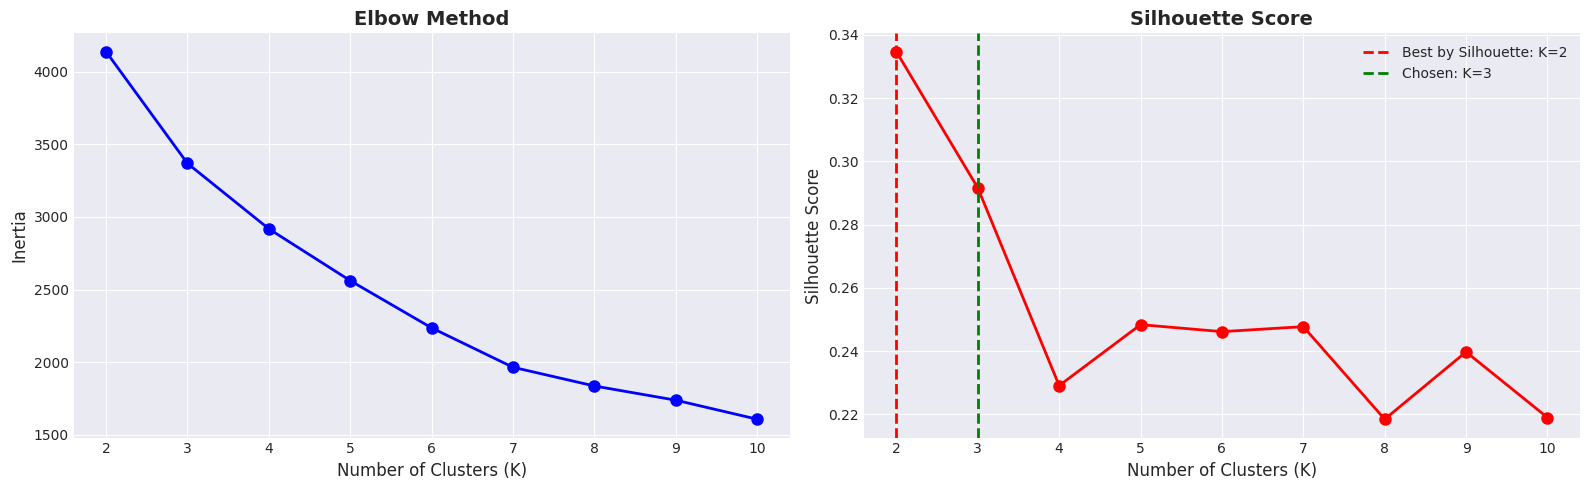

In [34]:
print("\n" + "="*70)
print("THUẬT TOÁN 3: K-MEANS CLUSTERING")
print("="*70)


# Tìm K tối ưu
print("\n Tìm số cluster tối ưu...")

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, kmeans_temp.labels_))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Method
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].grid(True)

# Tìm K tối ưu theo Silhouette
best_k_silhouette = K_range[np.argmax(silhouette_scores)]
axes[1].axvline(best_k_silhouette, color='red', linestyle='--', linewidth=2,
                label=f'Best by Silhouette: K={best_k_silhouette}')

# QUYẾT ĐỊNH K CUỐI CÙNG
if best_k_silhouette == 2:
    optimal_k = 3
    axes[1].axvline(optimal_k, color='green', linestyle='--', linewidth=2,
                    label=f'Chosen: K={optimal_k}')
else:
    optimal_k = best_k_silhouette

axes[1].legend()

plt.tight_layout()
plt.show()



In [36]:

print("\n" + "="*70)
print("HUẤN LUYỆN K-MEANS VÀ PHÂN TÍCH CLUSTERS")
print("="*70)


kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_profile['Cluster'] = kmeans_model.fit_predict(X_cluster)

# Đánh giá
silhouette_avg = silhouette_score(X_cluster, customer_profile['Cluster'])
print(f"\n Silhouette Score: {silhouette_avg:.4f}")
print(f" Inertia: {kmeans_model.inertia_:.2f}")

# Phân tích từng cluster
print("\n" + "="*70)
print("PHÂN TÍCH TỪNG CLUSTER")
print("="*70)

for cluster_id in range(optimal_k):
    cluster_data = customer_profile[customer_profile['Cluster'] == cluster_id]
    print(f"\n🔹 CLUSTER {cluster_id}:")
    print(f"   Số khách hàng: {len(cluster_data)} ({len(cluster_data)/len(customer_profile)*100:.1f}%)")
    print(f"   Tổng doanh thu TB: ${cluster_data['Total_Sales'].mean():,.2f}")
    print(f"   Doanh thu/đơn TB: ${cluster_data['Avg_Sales'].mean():,.2f}")
    print(f"   Số đơn hàng TB: {cluster_data['Order_Count'].mean():.1f}")
    print(f"   Lợi nhuận TB: ${cluster_data['Total_Profit'].mean():,.2f}")
    print(f"   Chiết khấu TB: {cluster_data['Avg_Discount'].mean():.2%}")

# Đặt tên cho clusters
cluster_names = {}
for cluster_id in range(optimal_k):
    cluster_data = customer_profile[customer_profile['Cluster'] == cluster_id]
    avg_sales = cluster_data['Total_Sales'].mean()
    avg_orders = cluster_data['Order_Count'].mean()

    if avg_sales > customer_profile['Total_Sales'].quantile(0.75):
        if avg_orders > customer_profile['Order_Count'].quantile(0.75):
            cluster_names[cluster_id] = "VIP - High Value"
        else:
            cluster_names[cluster_id] = "Big Spender"
    elif avg_sales > customer_profile['Total_Sales'].quantile(0.5):
        cluster_names[cluster_id] = "Regular Customer"
    else:
        if avg_orders < customer_profile['Order_Count'].quantile(0.25):
            cluster_names[cluster_id] = "New/Inactive"
        else:
            cluster_names[cluster_id] = "Low Value"

customer_profile['Cluster_Name'] = customer_profile['Cluster'].map(cluster_names)

print("\n PHÂN LOẠI KHÁCH HÀNG:")
for cluster_id, name in cluster_names.items():
    count = (customer_profile['Cluster'] == cluster_id).sum()
    print(f"   Cluster {cluster_id}: {name} ({count} khách hàng)")



HUẤN LUYỆN K-MEANS VÀ PHÂN TÍCH CLUSTERS

 Silhouette Score: 0.2916
 Inertia: 3367.97

PHÂN TÍCH TỪNG CLUSTER

🔹 CLUSTER 0:
   Số khách hàng: 482 (60.8%)
   Tổng doanh thu TB: $1,592.19
   Doanh thu/đơn TB: $182.57
   Số đơn hàng TB: 8.8
   Lợi nhuận TB: $94.68
   Chiết khấu TB: 16.35%

🔹 CLUSTER 1:
   Số khách hàng: 267 (33.7%)
   Tổng doanh thu TB: $4,165.14
   Doanh thu/đơn TB: $227.93
   Số đơn hàng TB: 18.8
   Lợi nhuận TB: $474.58
   Chiết khấu TB: 15.75%

🔹 CLUSTER 2:
   Số khách hàng: 44 (5.5%)
   Tổng doanh thu TB: $8,619.58
   Doanh thu/đơn TB: $736.77
   Số đơn hàng TB: 12.8
   Lợi nhuận TB: $2,420.95
   Chiết khấu TB: 10.23%

 PHÂN LOẠI KHÁCH HÀNG:
   Cluster 0: Low Value (482 khách hàng)
   Cluster 1: VIP - High Value (267 khách hàng)
   Cluster 2: Big Spender (44 khách hàng)



VISUALIZATION CLUSTERING RESULTS


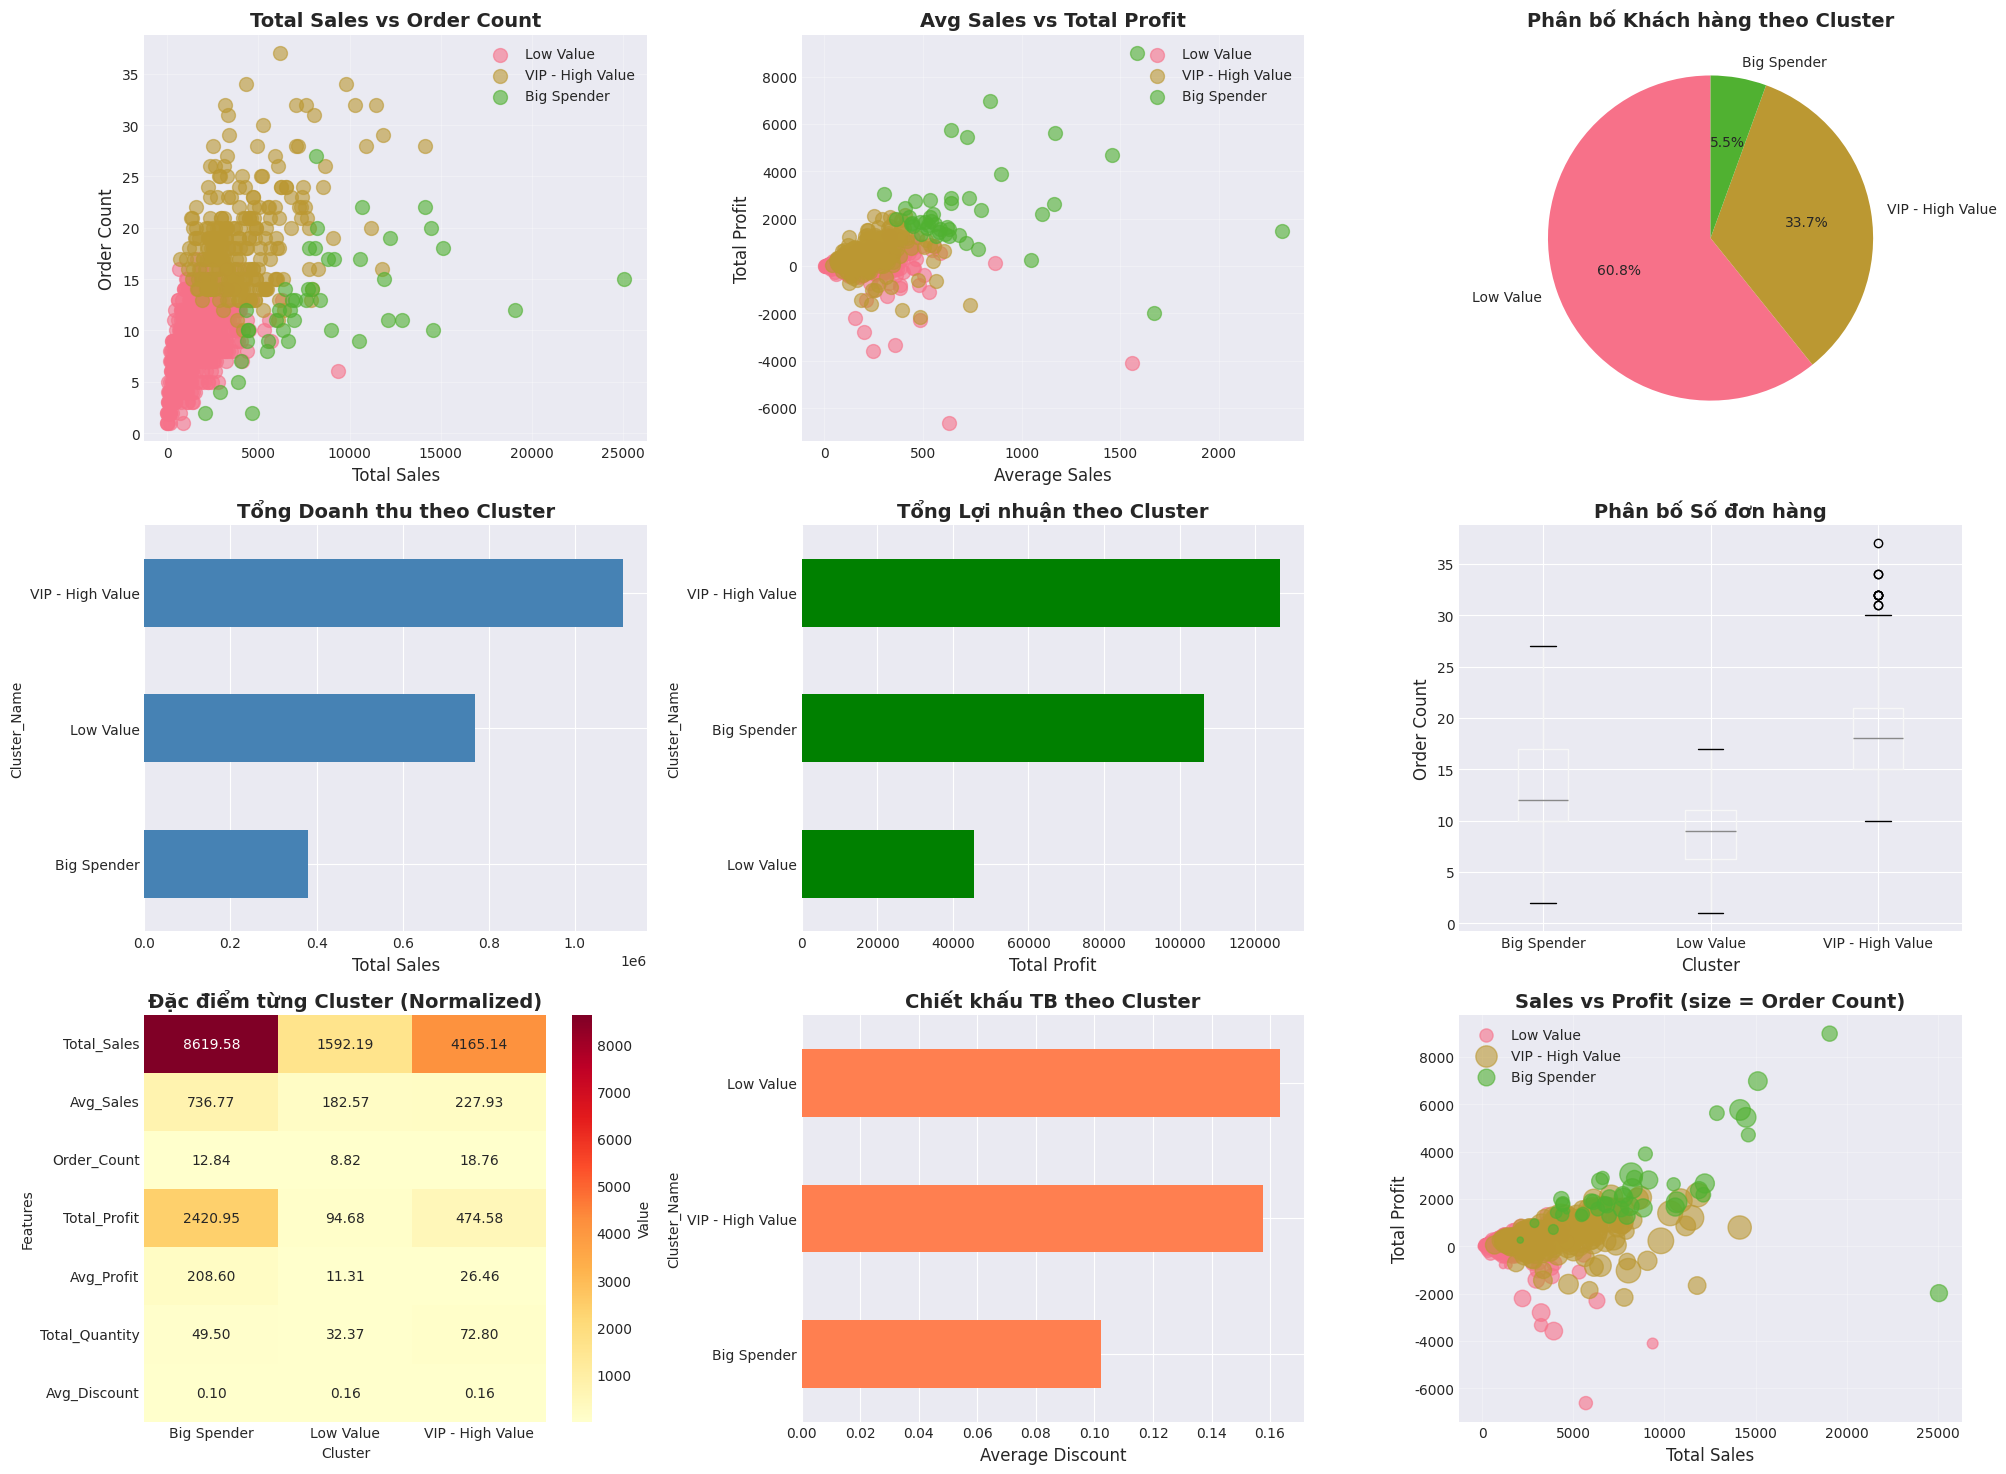

In [38]:

print("\n" + "="*70)
print("VISUALIZATION CLUSTERING RESULTS")
print("="*70)

# Tạo figure lớn với nhiều subplots
fig = plt.figure(figsize=(20, 15))

# 1. Scatter plot: Total Sales vs Order Count
plt.subplot(3, 3, 1)
for cluster_id in range(optimal_k):
    cluster_data = customer_profile[customer_profile['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Total_Sales'], cluster_data['Order_Count'],
                label=cluster_names[cluster_id], alpha=0.6, s=100)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.title('Total Sales vs Order Count', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Scatter plot: Avg Sales vs Total Profit
plt.subplot(3, 3, 2)
for cluster_id in range(optimal_k):
    cluster_data = customer_profile[customer_profile['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Avg_Sales'], cluster_data['Total_Profit'],
                label=cluster_names[cluster_id], alpha=0.6, s=100)
plt.xlabel('Average Sales', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.title('Avg Sales vs Total Profit', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Pie chart: Phân bố khách hàng
plt.subplot(3, 3, 3)
cluster_counts = customer_profile['Cluster_Name'].value_counts()
plt.pie(cluster_counts, labels=cluster_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Phân bố Khách hàng theo Cluster', fontsize=14, fontweight='bold')

# 4. Bar chart: Total Sales by Cluster
plt.subplot(3, 3, 4)
cluster_sales = customer_profile.groupby('Cluster_Name')['Total_Sales'].sum().sort_values()
cluster_sales.plot(kind='barh', color='steelblue')
plt.xlabel('Total Sales', fontsize=12)
plt.title('Tổng Doanh thu theo Cluster', fontsize=14, fontweight='bold')

# 5. Bar chart: Total Profit by Cluster
plt.subplot(3, 3, 5)
cluster_profit = customer_profile.groupby('Cluster_Name')['Total_Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'green' for x in cluster_profit]
cluster_profit.plot(kind='barh', color=colors)
plt.xlabel('Total Profit', fontsize=12)
plt.title('Tổng Lợi nhuận theo Cluster', fontsize=14, fontweight='bold')

# 6. Box plot: Order Count by Cluster
plt.subplot(3, 3, 6)
customer_profile.boxplot(column='Order_Count', by='Cluster_Name', ax=plt.gca())
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Order Count', fontsize=12)
plt.title('Phân bố Số đơn hàng', fontsize=14, fontweight='bold')
plt.suptitle('')

# 7. Heatmap: Cluster characteristics
plt.subplot(3, 3, 7)
cluster_summary = customer_profile.groupby('Cluster_Name')[clustering_features].mean()
sns.heatmap(cluster_summary.T, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Value'})
plt.title('Đặc điểm từng Cluster (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Features')

# 8. Bar chart: Average Discount by Cluster
plt.subplot(3, 3, 8)
cluster_discount = customer_profile.groupby('Cluster_Name')['Avg_Discount'].mean().sort_values()
cluster_discount.plot(kind='barh', color='coral')
plt.xlabel('Average Discount', fontsize=12)
plt.title('Chiết khấu TB theo Cluster', fontsize=14, fontweight='bold')

# 9. 3D Scatter (simplified to 2D with size)
plt.subplot(3, 3, 9)
for cluster_id in range(optimal_k):
    cluster_data = customer_profile[customer_profile['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Total_Sales'], cluster_data['Total_Profit'],
                s=cluster_data['Order_Count']*10,
                label=cluster_names[cluster_id], alpha=0.6)
plt.xlabel('Total Sales', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)
plt.title('Sales vs Profit (size = Order Count)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [48]:

print("="*70)
print("DANH SÁCH KHÁCH HÀNG VÀ CLUSTER")
print("="*70)


print("\n DANH SÁCH KHÁCH HÀNG ĐÃ ĐƯỢC GÁN CLUSTER:")
print("-"*70)

# Hiển thị 20 khách hàng đầu tiên
print("\n 20 KHÁCH HÀNG ĐẦU TIÊN:")
display(customer_profile[['Customer_ID', 'Cluster_Name', 'Total_Sales',
                          'Order_Count', 'Total_Profit', 'Avg_Discount']].head(20))

print("\n" + "="*70)
print("THỐNG KÊ THEO CLUSTER")
print("="*70)

for cluster_name in sorted(customer_profile['Cluster_Name'].unique()):
    cluster_customers = customer_profile[customer_profile['Cluster_Name'] == cluster_name]

    print(f"\n {cluster_name}:")
    print(f"   Số khách hàng: {len(cluster_customers)}")
    print(f"   Tỷ lệ: {len(cluster_customers)/len(customer_profile)*100:.1f}%")
    print(f"   Doanh thu TB: ${cluster_customers['Total_Sales'].mean():,.0f}")
    print(f"   Lợi nhuận TB: ${cluster_customers['Total_Profit'].mean():,.0f}")

    # Hiển thị 5 khách hàng mẫu
    print(f"\n    5 khách hàng mẫu:")
    sample = cluster_customers[['Customer_ID', 'Total_Sales', 'Order_Count']].head(5)
    for idx, row in sample.iterrows():
        print(f"      • {row['Customer_ID']}: ${row['Total_Sales']:,.0f} ({row['Order_Count']:.0f} đơn)")


print("\n" + "="*70)
print("LƯU DANH SÁCH KHÁCH HÀNG")
print("="*70)

# Tạo DataFrame đầy đủ
customer_list = customer_profile[['Customer_ID', 'Cluster', 'Cluster_Name',
                                   'Total_Sales', 'Avg_Sales', 'Order_Count',
                                   'Total_Profit', 'Avg_Profit', 'Total_Quantity',
                                   'Avg_Discount']].copy()

# Sắp xếp theo Cluster và Total_Sales
customer_list = customer_list.sort_values(['Cluster', 'Total_Sales'], ascending=[True, False])

# Lưu ra file CSV
customer_list.to_csv('customer_cluster_list.csv', index=False)
print(" Đã lưu danh sách vào file: customer_cluster_list.csv")

# Hiển thị thống kê
print(f"\n TỔNG QUAN:")
print(f"   Tổng số khách hàng: {len(customer_list)}")
print(f"   Số clusters: {customer_list['Cluster'].nunique()}")
print(f"\n   Phân bố:")
for cluster_name, count in customer_list['Cluster_Name'].value_counts().items():
    print(f"      • {cluster_name}: {count} khách ({count/len(customer_list)*100:.1f}%)")


DANH SÁCH KHÁCH HÀNG VÀ CLUSTER

 DANH SÁCH KHÁCH HÀNG ĐÃ ĐƯỢC GÁN CLUSTER:
----------------------------------------------------------------------

 20 KHÁCH HÀNG ĐẦU TIÊN:


,Customer_ID,Cluster_Name,Total_Sales,Order_Count,Total_Profit,Avg_Discount
0,AA-10315,Low Value,5563.560,11,-362.8825,0.090909
1,AA-10375,Low Value,1056.390,15,277.3824,0.080000
2,AA-10480,Low Value,1790.512,12,435.8274,0.016667
3,AA-10645,VIP - High Value,5086.935,18,857.8033,0.063889
4,AB-10015,Low Value,886.156,6,129.3465,0.066667
5,AB-10060,Big Spender,7755.620,18,2054.5885,0.044444
6,AB-10105,Big Spender,14473.571,20,5444.8055,0.240000
7,AB-10150,Low Value,966.710,12,313.6597,0.133333
8,AB-10165,Low Value,1113.838,14,220.8130,0.135714
9,AB-10255,Low Value,914.532,14,264.5675,0.100000



THỐNG KÊ THEO CLUSTER

 Big Spender:
   Số khách hàng: 44
   Tỷ lệ: 5.5%
   Doanh thu TB: $8,620
   Lợi nhuận TB: $2,421

    5 khách hàng mẫu:
      • AB-10060: $7,756 (18 đơn)
      • AB-10105: $14,474 (20 đơn)
      • AC-10450: $5,528 (9 đơn)
      • AD-10180: $6,107 (12 đơn)
      • AR-10540: $6,608 (9 đơn)

 Low Value:
   Số khách hàng: 482
   Tỷ lệ: 60.8%
   Doanh thu TB: $1,592
   Lợi nhuận TB: $95

    5 khách hàng mẫu:
      • AA-10315: $5,564 (11 đơn)
      • AA-10375: $1,056 (15 đơn)
      • AA-10480: $1,791 (12 đơn)
      • AB-10015: $886 (6 đơn)
      • AB-10150: $967 (12 đơn)

 VIP - High Value:
   Số khách hàng: 267
   Tỷ lệ: 33.7%
   Doanh thu TB: $4,165
   Lợi nhuận TB: $475

    5 khách hàng mẫu:
      • AA-10645: $5,087 (18 đơn)
      • AC-10615: $2,538 (18 đơn)
      • AF-10870: $2,053 (16 đơn)
      • AG-10270: $2,583 (14 đơn)
      • AG-10495: $2,357 (21 đơn)

LƯU DANH SÁCH KHÁCH HÀNG
 Đã lưu danh sách vào file: customer_cluster_list.csv

 TỔNG QUAN:
   Tổng số k

CLUSTER PROFILING - PHÂN TÍCH CHI TIẾT

🔗 Kết hợp dữ liệu cluster với dữ liệu gốc...

VISUALIZATION


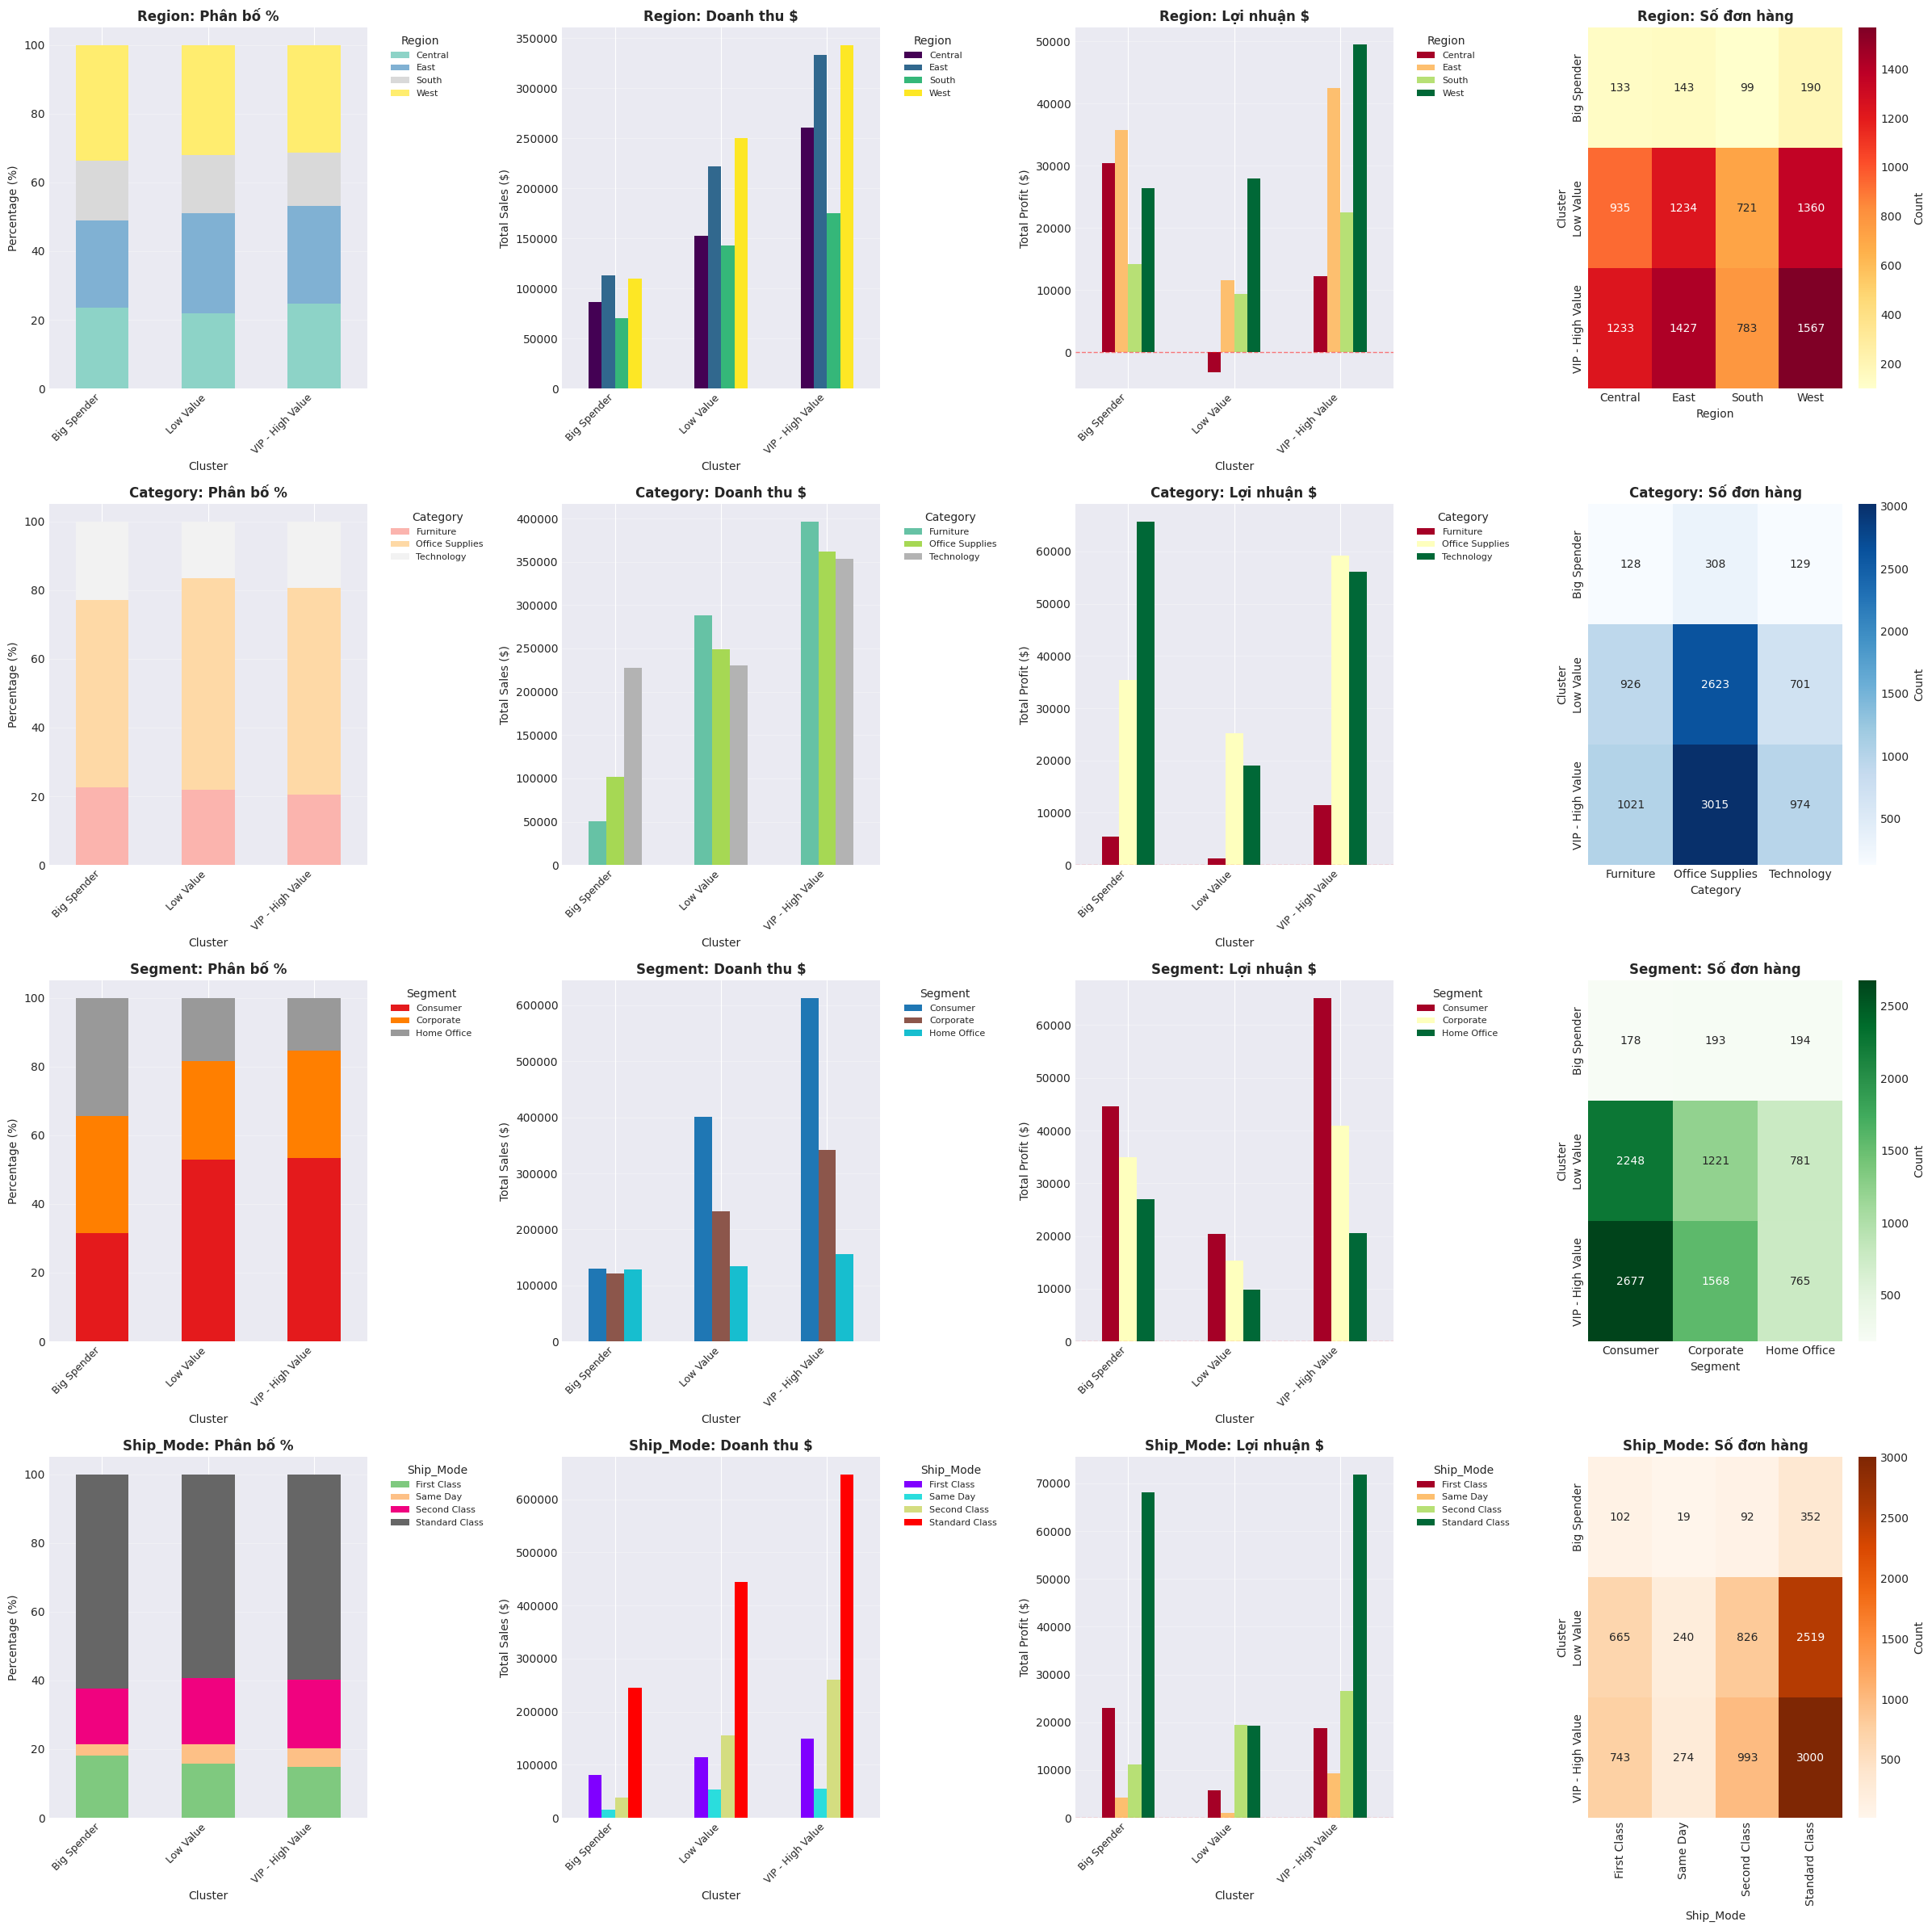


PHÂN TÍCH THEO THỜI GIAN


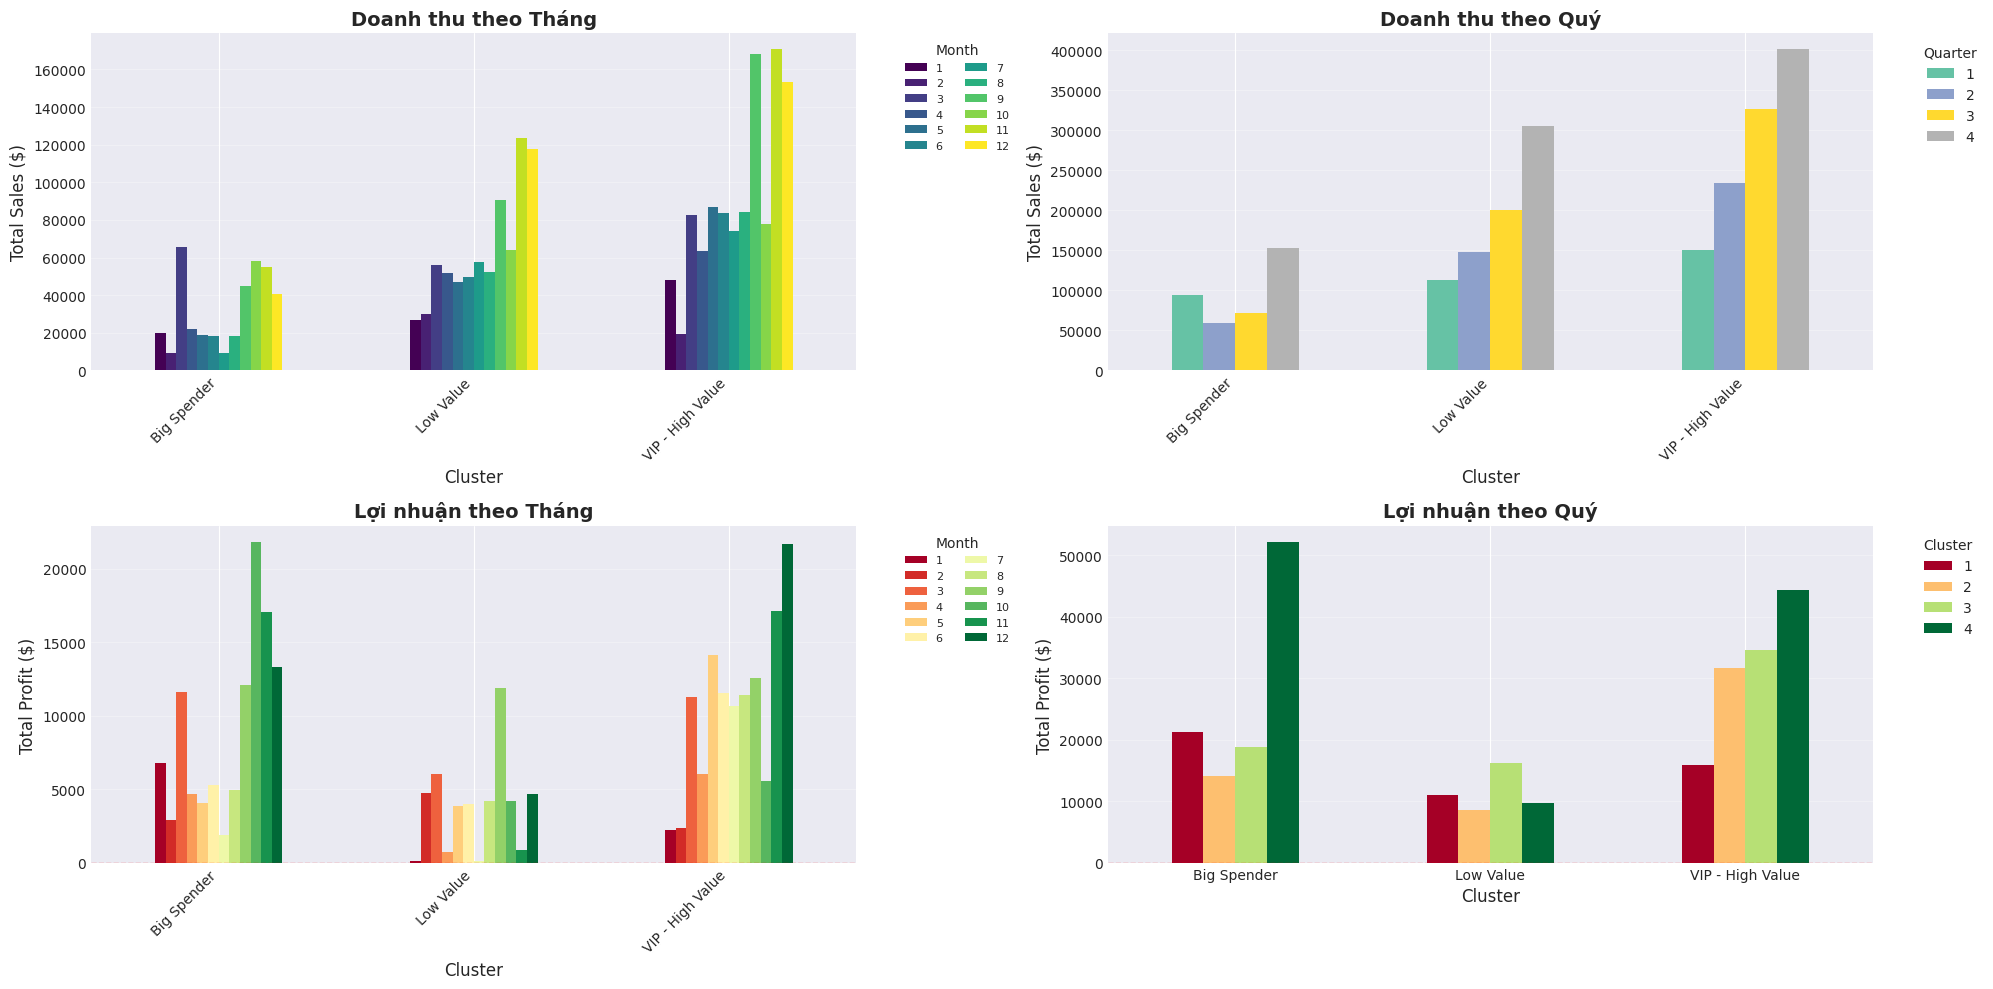

In [45]:

print("="*70)
print("CLUSTER PROFILING - PHÂN TÍCH CHI TIẾT")
print("="*70)

# ============================================================================
# BƯỚC 1: KẾT HỢP DỮ LIỆU CLUSTER VỚI DỮ LIỆU GỐC
# ============================================================================

print("\n🔗 Kết hợp dữ liệu cluster với dữ liệu gốc...")

# Merge customer_profile (có cluster) với df_encoded (có Region, Category, etc.)
df_with_cluster = df_encoded.merge(
    customer_profile[['Customer_ID', 'Cluster', 'Cluster_Name']],
    on='Customer_ID',
    how='left'
)


# REGION
region_pct = pd.crosstab(df_with_cluster['Cluster_Name'], df_with_cluster['Region'], normalize='index') * 100
region_sales = df_with_cluster.groupby(['Cluster_Name', 'Region'])['Sales'].sum().unstack()
region_profit = df_with_cluster.groupby(['Cluster_Name', 'Region'])['Profit'].sum().unstack()
region_count = pd.crosstab(df_with_cluster['Cluster_Name'], df_with_cluster['Region'])

# CATEGORY
category_pct = pd.crosstab(df_with_cluster['Cluster_Name'], df_with_cluster['Category'], normalize='index') * 100
category_sales = df_with_cluster.groupby(['Cluster_Name', 'Category'])['Sales'].sum().unstack()
category_profit = df_with_cluster.groupby(['Cluster_Name', 'Category'])['Profit'].sum().unstack()
category_count = pd.crosstab(df_with_cluster['Cluster_Name'], df_with_cluster['Category'])

# SEGMENT
segment_pct = pd.crosstab(df_with_cluster['Cluster_Name'], df_with_cluster['Segment'], normalize='index') * 100
segment_sales = df_with_cluster.groupby(['Cluster_Name', 'Segment'])['Sales'].sum().unstack()
segment_profit = df_with_cluster.groupby(['Cluster_Name', 'Segment'])['Profit'].sum().unstack()
segment_count = pd.crosstab(df_with_cluster['Cluster_Name'], df_with_cluster['Segment'])

# SHIP_MODE
shipmode_pct = pd.crosstab(df_with_cluster['Cluster_Name'], df_with_cluster['Ship_Mode'], normalize='index') * 100
shipmode_sales = df_with_cluster.groupby(['Cluster_Name', 'Ship_Mode'])['Sales'].sum().unstack()
shipmode_profit = df_with_cluster.groupby(['Cluster_Name', 'Ship_Mode'])['Profit'].sum().unstack()
shipmode_count = pd.crosstab(df_with_cluster['Cluster_Name'], df_with_cluster['Ship_Mode'])


print("\n" + "="*70)
print("VISUALIZATION")
print("="*70)

fig = plt.figure(figsize=(24, 24))


# 1.1 Region - Phân bố %
plt.subplot(4, 4, 1)
region_pct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set3')
plt.title('Region: Phân bố %', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Percentage (%)', fontsize=10)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# 1.2 Region - Doanh thu $
plt.subplot(4, 4, 2)
region_sales.plot(kind='bar', ax=plt.gca(), colormap='viridis')
plt.title('Region: Doanh thu $', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Total Sales ($)', fontsize=10)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# 1.3 Region - Lợi nhuận $
plt.subplot(4, 4, 3)
region_profit.plot(kind='bar', ax=plt.gca(), colormap='RdYlGn')
plt.title('Region: Lợi nhuận $', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Total Profit ($)', fontsize=10)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3, axis='y')

# 1.4 Region - Số đơn hàng
plt.subplot(4, 4, 4)
sns.heatmap(region_count, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
plt.title('Region: Số đơn hàng', fontsize=12, fontweight='bold')
plt.xlabel('Region', fontsize=10)
plt.ylabel('Cluster', fontsize=10)



# 2.1 Category - Phân bố %
plt.subplot(4, 4, 5)
category_pct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Pastel1')
plt.title('Category: Phân bố %', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Percentage (%)', fontsize=10)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# 2.2 Category - Doanh thu $
plt.subplot(4, 4, 6)
category_sales.plot(kind='bar', ax=plt.gca(), colormap='Set2')
plt.title('Category: Doanh thu $', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Total Sales ($)', fontsize=10)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# 2.3 Category - Lợi nhuận $
plt.subplot(4, 4, 7)
category_profit.plot(kind='bar', ax=plt.gca(), colormap='RdYlGn')
plt.title('Category: Lợi nhuận $', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Total Profit ($)', fontsize=10)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3, axis='y')

# 2.4 Category - Số đơn hàng
plt.subplot(4, 4, 8)
sns.heatmap(category_count, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title('Category: Số đơn hàng', fontsize=12, fontweight='bold')
plt.xlabel('Category', fontsize=10)
plt.ylabel('Cluster', fontsize=10)

# 3.1 Segment - Phân bố %
plt.subplot(4, 4, 9)
segment_pct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set1')
plt.title('Segment: Phân bố %', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Percentage (%)', fontsize=10)
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# 3.2 Segment - Doanh thu $
plt.subplot(4, 4, 10)
segment_sales.plot(kind='bar', ax=plt.gca(), colormap='tab10')
plt.title('Segment: Doanh thu $', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Total Sales ($)', fontsize=10)
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# 3.3 Segment - Lợi nhuận $
plt.subplot(4, 4, 11)
segment_profit.plot(kind='bar', ax=plt.gca(), colormap='RdYlGn')
plt.title('Segment: Lợi nhuận $', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Total Profit ($)', fontsize=10)
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3, axis='y')

# 3.4 Segment - Số đơn hàng
plt.subplot(4, 4, 12)
sns.heatmap(segment_count, annot=True, fmt='d', cmap='Greens', cbar_kws={'label': 'Count'})
plt.title('Segment: Số đơn hàng', fontsize=12, fontweight='bold')
plt.xlabel('Segment', fontsize=10)
plt.ylabel('Cluster', fontsize=10)

# 4.1 Ship_Mode - Phân bố %
plt.subplot(4, 4, 13)
shipmode_pct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Accent')
plt.title('Ship_Mode: Phân bố %', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Percentage (%)', fontsize=10)
plt.legend(title='Ship_Mode', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# 4.2 Ship_Mode - Doanh thu $
plt.subplot(4, 4, 14)
shipmode_sales.plot(kind='bar', ax=plt.gca(), colormap='rainbow')
plt.title('Ship_Mode: Doanh thu $', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Total Sales ($)', fontsize=10)
plt.legend(title='Ship_Mode', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# 4.3 Ship_Mode - Lợi nhuận $
plt.subplot(4, 4, 15)
shipmode_profit.plot(kind='bar', ax=plt.gca(), colormap='RdYlGn')
plt.title('Ship_Mode: Lợi nhuận $', fontsize=12, fontweight='bold')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Total Profit ($)', fontsize=10)
plt.legend(title='Ship_Mode', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3, axis='y')

# 4.4 Ship_Mode - Số đơn hàng
plt.subplot(4, 4, 16)
sns.heatmap(shipmode_count, annot=True, fmt='d', cmap='Oranges', cbar_kws={'label': 'Count'})
plt.title('Ship_Mode: Số đơn hàng', fontsize=12, fontweight='bold')
plt.xlabel('Ship_Mode', fontsize=10)
plt.ylabel('Cluster', fontsize=10)

plt.tight_layout()
plt.show()


print("\n" + "="*70)
print("PHÂN TÍCH THEO THỜI GIAN")
print("="*70)

# Tạo các biến thời gian
df_with_cluster['Year'] = df_with_cluster['Order_Date'].dt.year
df_with_cluster['Month'] = df_with_cluster['Order_Date'].dt.month
df_with_cluster['Quarter'] = df_with_cluster['Order_Date'].dt.quarter
df_with_cluster['Year_Month'] = df_with_cluster['Order_Date'].dt.to_period('M')

# Phân tích theo năm
yearly_analysis = df_with_cluster.groupby(['Cluster_Name', 'Year']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).reset_index()


# Phân tích theo tháng
monthly_analysis = df_with_cluster.groupby(['Cluster_Name', 'Month']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).reset_index()

# Phân tích theo quý
quarterly_analysis = df_with_cluster.groupby(['Cluster_Name', 'Quarter']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).reset_index()



fig = plt.figure(figsize=(20, 10))

# 1. Doanh thu theo Tháng
plt.subplot(2, 2, 1)
monthly_sales_pivot = monthly_analysis.pivot_table(values='Sales', index='Cluster_Name', columns='Month')
monthly_sales_pivot.plot(kind='bar', ax=plt.gca(), colormap='viridis')
plt.title('Doanh thu theo Tháng', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# 2. Doanh thu theo Quý
plt.subplot(2, 2, 2)
quarterly_sales_pivot = quarterly_analysis.pivot_table(values='Sales', index='Cluster_Name', columns='Quarter')
quarterly_sales_pivot.plot(kind='bar', ax=plt.gca(), colormap='Set2')
plt.title('Doanh thu theo Quý', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(title='Quarter', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# 3. Lợi nhuận theo Tháng
plt.subplot(2, 2, 3)
monthly_profit_pivot = monthly_analysis.pivot_table(values='Profit', index='Cluster_Name', columns='Month')
monthly_profit_pivot.plot(kind='bar', ax=plt.gca(), colormap='RdYlGn')
plt.title('Lợi nhuận theo Tháng', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3, axis='y')

# 4. Lợi nhuận theo Quý
plt.subplot(2, 2, 4)
quarterly_profit_pivot = quarterly_analysis.pivot_table(values='Profit', index='Cluster_Name', columns='Quarter')
quarterly_profit_pivot.plot(kind='bar', ax=plt.gca(), colormap='RdYlGn')
plt.title('Lợi nhuận theo Quý', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
